In [1]:
# Cell 1: Install dependencies
# ─────────────────────────────────────────────────────────────────────────────
# Core libraries for dataset loading, fine-tuning, and evaluation.
# PySastrawi : Indonesian stemmer (used during preprocessing)
# emoji      : converts Unicode emoji to descriptive text tokens
!pip install -q \
    "datasets>=2.21.0" \
    "pyarrow>=14.0.1" \
    "transformers>=4.40.0" \
    "accelerate>=0.30.0" \
    seaborn \
    scikit-learn \
    PySastrawi \
    emoji


In [2]:
# Cell 2: Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import copy
import math
import glob
import warnings
import inspect
from dataclasses import dataclass
from typing import Any, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score as sk_f1,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    TrainerCallback,
    EvalPrediction,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")
print("✓ Imports done.")


✓ Imports done.


In [3]:
# Cell 3: Device detection
# ─────────────────────────────────────────────────────────────────────────────
def get_device():
    try:
        import torch_xla.core.xla_model as xm
        device = xm.xla_device()
        print(f"Device   : TPU  ({device})")
        return device, "tpu"
    except ImportError:
        pass

    if torch.cuda.is_available():
        device   = torch.device("cuda")
        gpu_name = torch.cuda.get_device_name(0)
        try:
            _ = torch.zeros(1, device=device) + torch.zeros(1, device=device)
            torch.cuda.synchronize()
            cap = torch.cuda.get_device_capability(0)
            print(f"Device   : {device}")
            print(f"GPU      : {gpu_name}")
            print(f"Compute  : sm_{cap[0]}{cap[1]}")
            print(f"PyTorch  : {torch.__version__}")
            print(f"CUDA     : {torch.version.cuda}")
            return device, "gpu"
        except (RuntimeError, Exception) as e:
            warnings.warn(f"GPU '{gpu_name}' detected but incompatible. Falling back to CPU.",
                          RuntimeWarning, stacklevel=2)

    device = torch.device("cpu")
    print("Device   : CPU (training will be slow)")
    return device, "cpu"


print(f"PyTorch  : {torch.__version__}")
DEVICE, DEVICE_TYPE = get_device()

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
COLORS = {
    "Teacher"                : "#4C72B0",
    "Self-Distilled Teacher" : "#8172B2",
    "Student no KD"          : "#DD8452",
    "Student with KD"        : "#55A868",
}


PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4
Compute  : sm_75
PyTorch  : 2.10.0+cu128
CUDA     : 12.8


In [4]:
# Cell 4: Hyperparameters & global configuration
# ─────────────────────────────────────────────────────────────────────────────
# Teacher : indobenchmark/indobert-base-p1
#   → IndoBERT pre-trained on large Indonesian corpus
#   → https://huggingface.co/indobenchmark/indobert-base-p1
#
# Student : distilbert-base-multilingual-cased
#   → 6-layer multilingual DistilBERT; ~40% fewer parameters than BERT-base

# ── Model identifiers ─────────────────────────────────────────────────────────
TEACHER_NAME     = "indobenchmark/indobert-base-p1"
STUDENT_NAME     = "distilbert-base-multilingual-cased"
MAX_LENGTH       = 128

# ── Training hyperparameters ──────────────────────────────────────────────────
TEACHER_LR       = 2e-5
STUDENT_LR       = 3e-5
NUM_EPOCHS       = 5
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE  = 32
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1

# ── Early stopping ────────────────────────────────────────────────────────────
EARLY_STOPPING_PATIENCE = 2

# ── Self-distillation ─────────────────────────────────────────────────────────
SD_TEMPERATURE       = 4
SD_ALPHA             = 0.7
TEACHER_F1_THRESHOLD = 0.80

# ── Vanilla KD hyperparameters ────────────────────────────────────────────────
# α : weight for KL divergence loss (soft targets from teacher)
# 1-α : weight for CE loss (hard labels)
# Temperature T softens the probability distributions
KD_ALPHA       = 0.5   # balance between soft (KL) and hard (CE) targets
KD_TEMPERATURE = 2.0   # higher T → softer distributions → more info from teacher

# ── Label smoothing ───────────────────────────────────────────────────────────
LABEL_SMOOTHING = 0.1

# ── Class weighting ───────────────────────────────────────────────────────────
USE_CLASS_WEIGHT = True   # enabled: train imbalance ratio is 5.62x

# ── Dataset split ratios ──────────────────────────────────────────────────────
MANUAL_SPLIT      = True
TRAIN_RATIO       = 0.80
VAL_RATIO         = 0.10
RANDOM_SEED       = 42

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded.")
print(f"  Teacher model        : {TEACHER_NAME}")
print(f"  Student model        : {STUDENT_NAME}")
print(f"  KD Temperature (T)   : {KD_TEMPERATURE}")
print(f"  KD Alpha (α)         : {KD_ALPHA}  (α * KL + (1-α) * CE)")
print(f"  Label smoothing      : {LABEL_SMOOTHING}")
print(f"  Weight decay (L2)    : {WEIGHT_DECAY}")
print(f"  Early stopping       : patience={EARLY_STOPPING_PATIENCE}")


Configuration loaded.
  Teacher model        : indobenchmark/indobert-base-p1
  Student model        : distilbert-base-multilingual-cased
  KD Temperature (T)   : 2.0
  KD Alpha (α)         : 0.5  (α * KL + (1-α) * CE)
  Label smoothing      : 0.1
  Weight decay (L2)    : 0.01
  Early stopping       : patience=2


In [5]:
# Cell 5: Load dataset — alvinhanafie/dataset-for-indonesian-sentiment-analysis
# ─────────────────────────────────────────────────────────────────────────────
# The original test split (test_preprocess_masked_label.tsv) has all labels
# masked as "neutral", making it useless for evaluation.
# We load all three TSV files, combine them into one pool, then re-split
# properly with stratification in Cell 9.

INPUT_DIR = "/kaggle/input"

all_files = (
    glob.glob(os.path.join(INPUT_DIR, "**/*.tsv"), recursive=True) +
    glob.glob(os.path.join(INPUT_DIR, "**/*.csv"), recursive=True)
)
print(f"Files found: {all_files}")
assert len(all_files) > 0, "No TSV/CSV files found in /kaggle/input. Make sure the dataset is attached."

def read_file(path: str) -> pd.DataFrame:
    sep = "\t" if path.endswith(".tsv") else ","
    return pd.read_csv(path, sep=sep)

# Load and tag each file so we can see where data came from
dfs = []
for f in all_files:
    df_part = read_file(f)
    df_part["_source"] = os.path.basename(f)
    dfs.append(df_part)
    print(f"  Loaded {os.path.basename(f)}: {len(df_part)} rows, columns={df_part.columns.tolist()}")

# Combine everything into one pool — re-splitting happens in Cell 9
df_raw = pd.concat(dfs, ignore_index=True)
df_raw = df_raw.drop(columns=["_source"], errors="ignore")

print(f"\nCombined shape : {df_raw.shape}")
print(f"Columns        : {df_raw.columns.tolist()}")
print(f"\nSample (first 3 rows):")
print(df_raw.head(3))
print(f"\nNull values:\n{df_raw.isnull().sum()}")

# has_presplit=False because we are intentionally re-splitting from scratch
has_presplit = False
df_splits    = None


Files found: ['/kaggle/input/datasets/alvinhanafie/dataset-for-indonesian-sentiment-analysis/train_preprocess_ori.tsv', '/kaggle/input/datasets/alvinhanafie/dataset-for-indonesian-sentiment-analysis/valid_preprocess.tsv', '/kaggle/input/datasets/alvinhanafie/dataset-for-indonesian-sentiment-analysis/test_preprocess_masked_label.tsv']
  Loaded train_preprocess_ori.tsv: 11000 rows, columns=['text', 'sentiment', '_source']
  Loaded valid_preprocess.tsv: 1260 rows, columns=['text', 'sentiment', '_source']
  Loaded test_preprocess_masked_label.tsv: 500 rows, columns=['text', 'sentiment', '_source']

Combined shape : (12760, 2)
Columns        : ['text', 'sentiment']

Sample (first 3 rows):
                                                text sentiment
0  warung ini dimiliki oleh pengusaha pabrik tahu...  positive
1  mohon ulama lurus dan k212 mmbri hujjah partai...   neutral
2  lokasi strategis di jalan sumatera bandung . t...  positive

Null values:
text         0
sentiment    0
dtype: int6

In [6]:
# Cell 6: Auto-detect text and label columns
# ─────────────────────────────────────────────────────────────────────────────
# ── MANUAL OVERRIDE ───────────────────────────────────────────────────────────
# If auto-detection is wrong, uncomment and fill in manually:
# TEXT_COL_RAW  = "Tweet"       # Name of the text column in your CSV
# LABEL_COL_RAW = "label"       # Name of the label column in your CSV
# ─────────────────────────────────────────────────────────────────────────────

# Candidate column names for text and label
_TEXT_CANDIDATES  = ["text", "Text", "review", "Review", "tweet", "Tweet",
                     "kalimat", "Kalimat", "sentence", "Sentence", "content", "Content"]
_LABEL_CANDIDATES = ["label", "Label", "sentiment", "Sentiment", "polarity",
                     "Polarity", "kelas", "Kelas", "kategori", "Kategori"]

cols = df_raw.columns.tolist()

try:
    TEXT_COL_RAW
except NameError:
    # Auto-detect
    TEXT_COL_RAW = next((c for c in _TEXT_CANDIDATES if c in cols), None)
    if TEXT_COL_RAW is None:
        # Fallback: string column with the longest average length
        str_cols = df_raw.select_dtypes(include="object").columns.tolist()
        TEXT_COL_RAW = max(str_cols, key=lambda c: df_raw[c].str.len().mean())
        print(f"[WARN] Text column not found from candidates, using fallback: '{TEXT_COL_RAW}'")

try:
    LABEL_COL_RAW
except NameError:
    LABEL_COL_RAW = next((c for c in _LABEL_CANDIDATES if c in cols), None)
    if LABEL_COL_RAW is None:
        # Fallback: object column with the lowest cardinality (likely a label column)
        str_cols = df_raw.select_dtypes(include="object").columns.tolist()
        str_cols = [c for c in str_cols if c != TEXT_COL_RAW]
        LABEL_COL_RAW = min(str_cols, key=lambda c: df_raw[c].nunique())
        print(f"[WARN] Label column not found from candidates, using fallback: '{LABEL_COL_RAW}'")

print(f"Text column  : '{TEXT_COL_RAW}'")
print(f"Label column : '{LABEL_COL_RAW}'")
print(f"\nLabel distribution:")
print(df_raw[LABEL_COL_RAW].value_counts())


Text column  : 'text'
Label column : 'sentiment'

Label distribution:
sentiment
positive    7151
negative    3830
neutral     1779
Name: count, dtype: int64


In [7]:
# Cell 7: Normalize labels → lowercase English strings
# ─────────────────────────────────────────────────────────────────────────────
# The dataset may use 'Positif'/'Negatif'/'Netral' (Indonesian), or
# 'positive'/'negative'/'neutral' (English), or integers 1/0/-1.
# This cell standardizes everything to lowercase English.
#
# ── MANUAL OVERRIDE ───────────────────────────────────────────────────────────
# If your label mapping differs, edit the LABEL_MAP dict below:
# LABEL_MAP = {
#     "Positif": "positive", "positif": "positive", "1": "positive", 1: "positive",
#     "Negatif": "negative", "negatif": "negative", "-1": "negative", -1: "negative",
#     "Netral" : "neutral",  "netral" : "neutral",  "0": "neutral",  0: "neutral",
# }
# ─────────────────────────────────────────────────────────────────────────────

try:
    LABEL_MAP
except NameError:
    # Auto-build mapping from unique values
    unique_labels = df_raw[LABEL_COL_RAW].dropna().unique()
    print(f"Unique labels found: {unique_labels}")

    LABEL_MAP = {}
    for lbl in unique_labels:
        s = str(lbl).strip().lower()
        if s in ("positif", "positive", "pos", "1", "1.0"):
            LABEL_MAP[lbl] = "positive"
        elif s in ("negatif", "negative", "neg", "-1", "-1.0"):
            LABEL_MAP[lbl] = "negative"
        elif s in ("netral", "neutral", "net", "0", "0.0"):
            LABEL_MAP[lbl] = "neutral"
        else:
            LABEL_MAP[lbl] = s  # Keep as-is if unrecognized

print(f"Label mapping: {LABEL_MAP}")

VALID_LABELS = set(LABEL_MAP.values())
print(f"Valid labels : {VALID_LABELS}")


Unique labels found: ['positive' 'neutral' 'negative']
Label mapping: {'positive': 'positive', 'neutral': 'neutral', 'negative': 'negative'}
Valid labels : {'positive', 'neutral', 'negative'}


In [8]:
# Cell 8: Preprocessing — text cleaning and column normalization
# ─────────────────────────────────────────────────────────────────────────────
import re
import emoji

# Slang / informal abbreviation dictionary
SLANG_DICT = {
    "gak": "tidak",  "ga": "tidak",   "nggak": "tidak", "ngga": "tidak",
    "gk":  "tidak",  "tdk": "tidak",
    "udah": "sudah", "udh":  "sudah", "sdh":   "sudah",
    "yg":  "yang",   "dgn":  "dengan","utk":   "untuk",
    "lg":  "lagi",   "lgi":  "lagi",
    "tp":  "tapi",   "tpi":  "tapi",
    "jg":  "juga",
    "blm": "belum",  "blum": "belum",
    "bgt": "banget", "bngt": "banget",
    "krn": "karena", "karna":"karena",
    "emg": "memang", "emang":"memang",
    "kalo":"kalau",  "klo":  "kalau", "klw":  "kalau",
    "hrs": "harus",
    "sy":  "saya",   "gue":  "saya",  "gw":   "saya",
    "km":  "kamu",   "lo":   "kamu",  "lu":   "kamu",
    "dr":  "dari",   "dmn":  "dimana","knp":  "kenapa",
    "sm":  "sama",   "brg":  "bareng",
    "bs":  "bisa",   "bsa":  "bisa",
    "msh": "masih",  "msih": "masih",
    "jd":  "jadi",   "jdi":  "jadi",
    "spy": "supaya",
    "ttg": "tentang",
    "trs": "terus",  "truz": "terus",
    "dg":  "dengan",
    "mk":  "maka",   "pd":   "pada",
    "sbg": "sebagai","spt":  "seperti",
    "stlh":"setelah","sblm": "sebelum",
    "org": "orang",  "tau":  "tahu",
    "nih": "ini",    "ni":   "ini",
    "yah": "ya",     "yaah": "ya",
    "wkwk": "", "wkwkwk": "", "haha": "", "hehe": "", "xixi": "", "hihi": "",
}


def normalize_slang(text: str) -> str:
    words = text.split()
    out   = [SLANG_DICT.get(w.lower(), w) for w in words]
    return " ".join(w for w in out if w)


def clean_text(txt: str) -> Optional[str]:
    if not isinstance(txt, str):
        return None
    txt = txt.lower()
    txt = emoji.demojize(txt, delimiters=(" ", " "))
    txt = re.sub(r":[a-z_]+:", " ", txt)
    txt = re.sub(r"https?://\S+|www\.\S+", " ", txt)
    txt = re.sub(r"@\w+", " ", txt)
    txt = re.sub(r"#(\w+)", r"\1", txt)
    txt = re.sub(r"(.)\1{2,}", r"\1\1", txt)
    txt = re.sub(r"\b\d+\b", " ", txt)
    txt = re.sub(r"[^a-zA-Z\s]", " ", txt)
    txt = normalize_slang(txt)
    txt = re.sub(r"[\r\n\t]+", " ", txt)
    txt = re.sub(r" {2,}", " ", txt).strip()
    return txt if len(txt) >= 3 else None


def normalize_row(example: dict) -> dict:
    raw_txt = example.get("text_raw", "")
    txt     = clean_text(raw_txt)
    raw_lbl = example.get("label_raw")
    lbl     = LABEL_MAP.get(raw_lbl, str(raw_lbl).strip().lower() if raw_lbl is not None else "")
    valid   = (txt is not None) and (lbl in VALID_LABELS)
    return {"text": txt or "", "raw_text": str(raw_txt), "label": lbl, "valid": valid}


# ── Build df_clean (used only in single-file / MANUAL_SPLIT mode) ─────────────
# When the dataset ships as pre-split files (has_presplit=True), df_clean is
# assembled in Cell 9 after each split is cleaned independently.
# Here we build it only for the single-file path so Cell 9 has something to work with.
if not has_presplit:
    df_input = df_raw[[TEXT_COL_RAW, LABEL_COL_RAW]].copy()
    df_input.columns = ["text_raw", "label_raw"]
    df_input = df_input.dropna(subset=["text_raw", "label_raw"]).reset_index(drop=True)

    ds_full  = Dataset.from_pandas(df_input, preserve_index=False)
    ds_full  = ds_full.map(normalize_row, remove_columns=ds_full.column_names)
    ds_full  = ds_full.filter(lambda x: x["valid"])
    ds_full  = ds_full.remove_columns(["valid"])

    df_clean = ds_full.to_pandas().drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    print(f"Total samples after cleaning: {len(df_clean)} rows")
    print(f"\nLabel distribution after cleaning:")
    print(df_clean["label"].value_counts())
    print(f"\nBefore/After examples (first 3):")
    for _, row in df_clean.head(3).iterrows():
        print(f"  BEFORE : {row['raw_text'][:90]}")
        print(f"  AFTER  : {row['text'][:90]}")
        print(f"  LABEL  : {row['label']}\n")
else:
    print("Pre-split mode — df_clean will be assembled in Cell 9 after per-split cleaning.")
    print(f"Column detection source: combined df_raw ({len(df_raw)} rows)")


Map:   0%|          | 0/12760 [00:00<?, ? examples/s]

Filter:   0%|          | 0/12760 [00:00<?, ? examples/s]

Total samples after cleaning: 12674 rows

Label distribution after cleaning:
label
positive    7109
negative    3800
neutral     1765
Name: count, dtype: int64

Before/After examples (first 3):
  BEFORE : warung ini dimiliki oleh pengusaha pabrik tahu yang sudah puluhan tahun terkenal membuat t
  AFTER  : warung ini dimiliki oleh pengusaha pabrik tahu yang sudah puluhan tahun terkenal membuat t
  LABEL  : positive

  BEFORE : mohon ulama lurus dan k212 mmbri hujjah partai apa yang harus diwlh agar suara islam tidak
  AFTER  : mohon ulama lurus dan k mmbri hujjah partai apa yang harus diwlh agar suara islam tidak pe
  LABEL  : neutral

  BEFORE : lokasi strategis di jalan sumatera bandung . tempat nya nyaman terutama sofa di lantai 2 .
  AFTER  : lokasi strategis di jalan sumatera bandung tempat nya nyaman terutama sofa di lantai paell
  LABEL  : positive



In [9]:
# Cell 9: Stratified re-split → train / validation / test
# ─────────────────────────────────────────────────────────────────────────────
# The original test file had masked labels (all neutral), so we combine
# everything and re-split with stratify to get proper class distribution
# in every split.
#
# Ratios: Train 80% | Validation 10% | Test 10%

# Step 1: train (80%) vs temp (20%)
df_train, df_temp = train_test_split(
    df_clean,
    test_size=1 - TRAIN_RATIO,          # 0.20
    random_state=RANDOM_SEED,
    stratify=df_clean["label"],
)

# Step 2: validation (10%) vs test (10%) from the 20% temp pool
val_frac = VAL_RATIO / (1 - TRAIN_RATIO)   # 0.10 / 0.20 = 0.50
df_val, df_test = train_test_split(
    df_temp,
    test_size=1 - val_frac,             # 0.50
    random_state=RANDOM_SEED,
    stratify=df_temp["label"],
)

# ── Neutral oversampling on df_train (train only — val/test stay untouched) ────
# We upsample 'neutral' rows in df_train until each class has at least as many
# samples as the median class count. This directly targets the low recall (0.41)
# on neutral without touching val/test integrity.
_label_col = "label"
_counts     = df_train[_label_col].value_counts()
_target_n   = int(_counts.median())           # upsample minorities to median count
print(f"\nOversampling target per class: {_target_n} (median count)")

_balanced_parts = []
for _lbl, _cnt in _counts.items():
    _subset = df_train[df_train[_label_col] == _lbl]
    if _cnt < _target_n:
        _subset = _subset.sample(_target_n, replace=True, random_state=RANDOM_SEED)
        print(f"  Upsampled  '{_lbl}': {_cnt} → {_target_n}")
    else:
        print(f"  Kept       '{_lbl}': {_cnt} (at or above target)")
    _balanced_parts.append(_subset)

df_train = pd.concat(_balanced_parts).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"\n✓ Balanced df_train size: {len(df_train)}")
print(df_train[_label_col].value_counts().to_string())

raw_datasets = DatasetDict({
    "train":      Dataset.from_pandas(df_train.reset_index(drop=True), preserve_index=False),
    "validation": Dataset.from_pandas(df_val.reset_index(drop=True),   preserve_index=False),
    "test":       Dataset.from_pandas(df_test.reset_index(drop=True),  preserve_index=False),
})

# ── Verify class distribution in each split ───────────────────────────────────
print(f"✓ Re-split complete (stratified, seed={RANDOM_SEED}):")
print(f"  Train      : {len(df_train)} samples")
print(f"  Validation : {len(df_val)} samples")
print(f"  Test       : {len(df_test)} samples")

for split_name, df_sp in [("Train", df_train), ("Validation", df_val), ("Test", df_test)]:
    print(f"\n[{split_name}] label distribution:")
    vc = df_sp["label"].value_counts()
    for lbl, cnt in vc.items():
        pct = cnt / len(df_sp) * 100
        print(f"  {lbl:<12}: {cnt:>5}  ({pct:.1f}%)")
    unique_classes = df_sp["label"].nunique()
    if unique_classes < len(set(df_clean["label"])):
        print(f"  ⚠ WARNING: only {unique_classes} classes present in this split!")
    else:
        print(f"  ✓ All {unique_classes} classes present")



Oversampling target per class: 3040 (median count)
  Kept       'positive': 5687 (at or above target)
  Kept       'negative': 3040 (at or above target)
  Upsampled  'neutral': 1412 → 3040

✓ Balanced df_train size: 11767
label
positive    5687
neutral     3040
negative    3040
✓ Re-split complete (stratified, seed=42):
  Train      : 11767 samples
  Validation : 1267 samples
  Test       : 1268 samples

[Train] label distribution:
  positive    :  5687  (48.3%)
  neutral     :  3040  (25.8%)
  negative    :  3040  (25.8%)
  ✓ All 3 classes present

[Validation] label distribution:
  positive    :   711  (56.1%)
  negative    :   380  (30.0%)
  neutral     :   176  (13.9%)
  ✓ All 3 classes present

[Test] label distribution:
  positive    :   711  (56.1%)
  negative    :   380  (30.0%)
  neutral     :   177  (14.0%)
  ✓ All 3 classes present


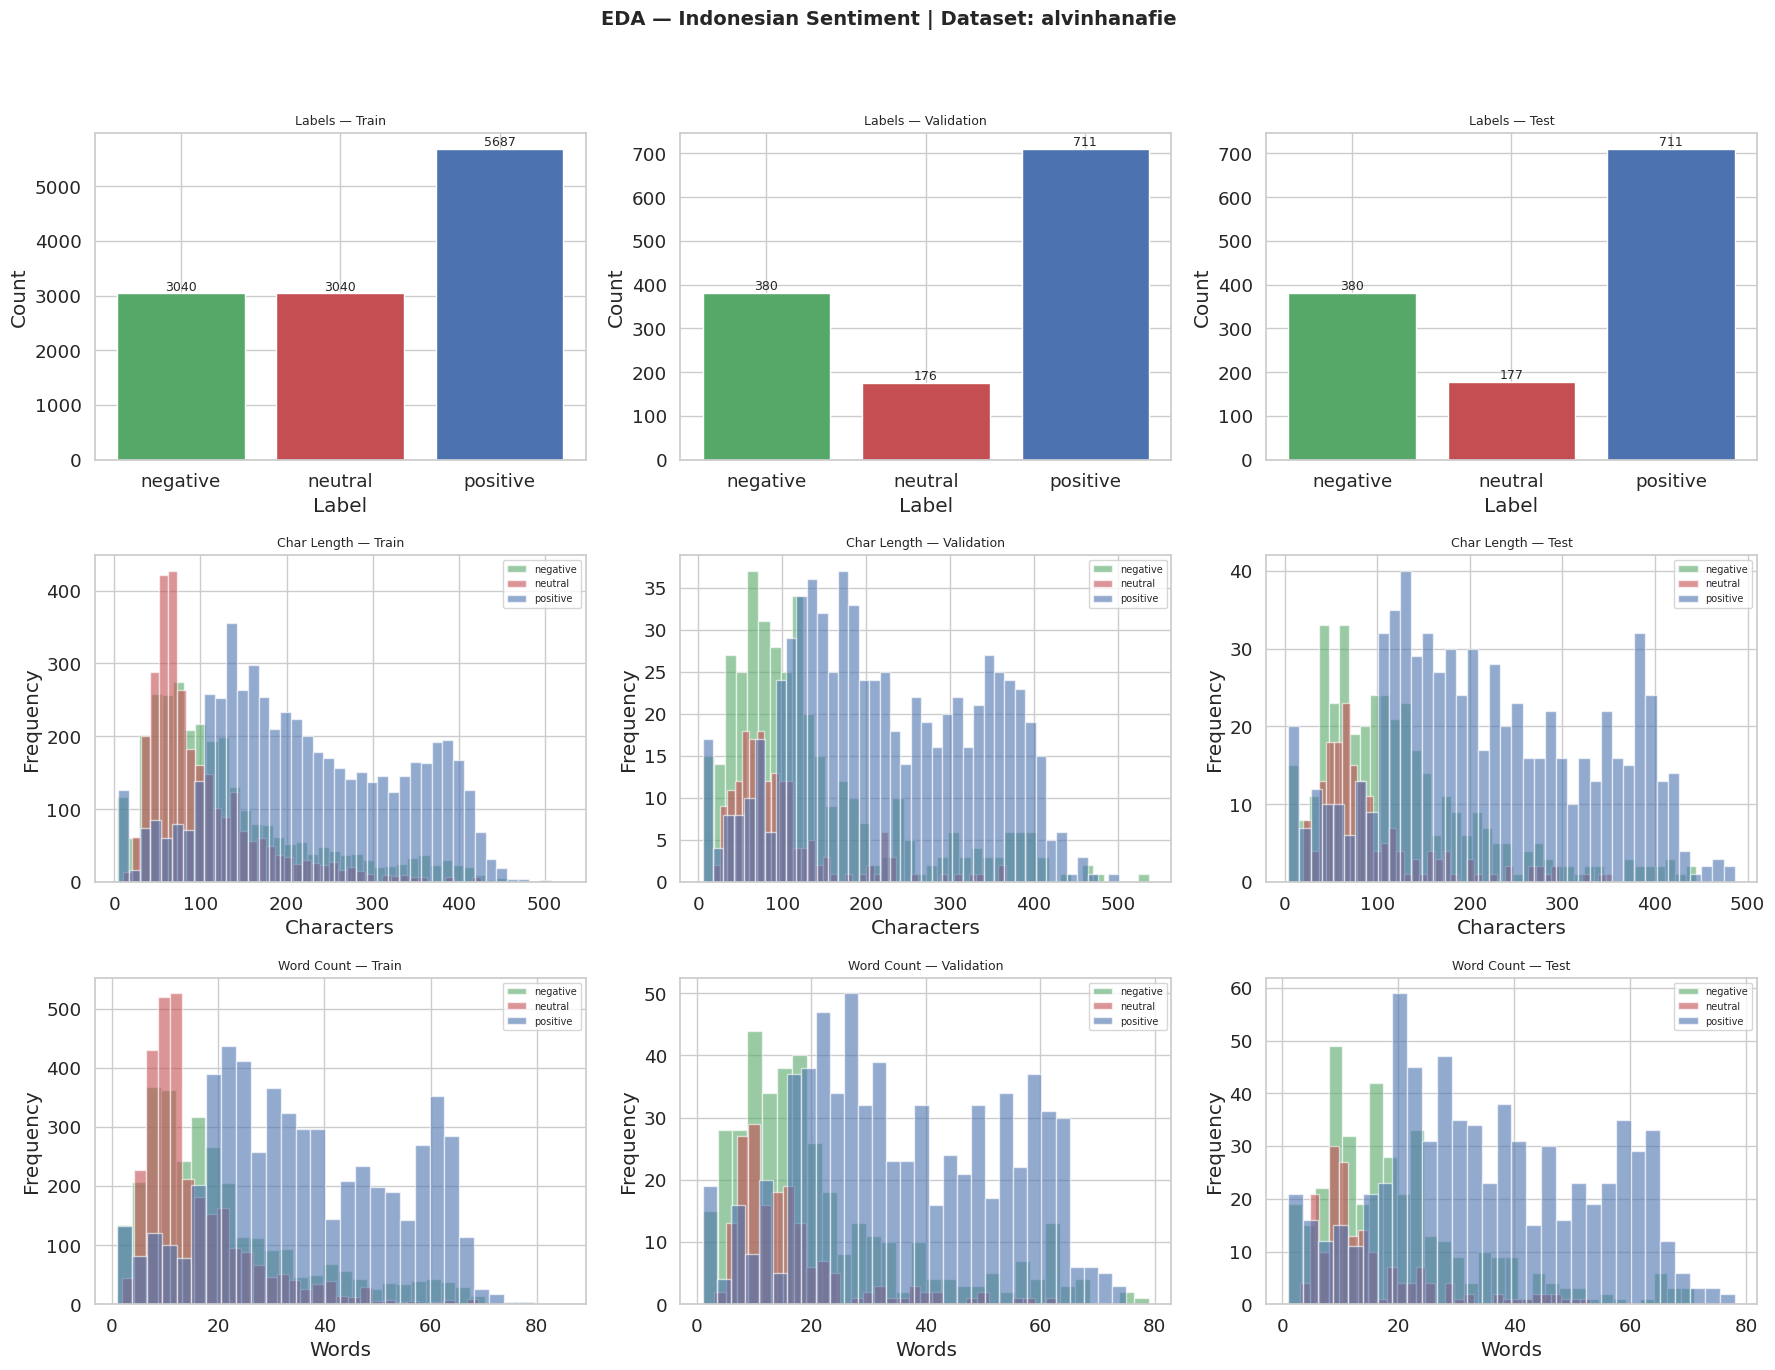

Saved: eda_overview.png


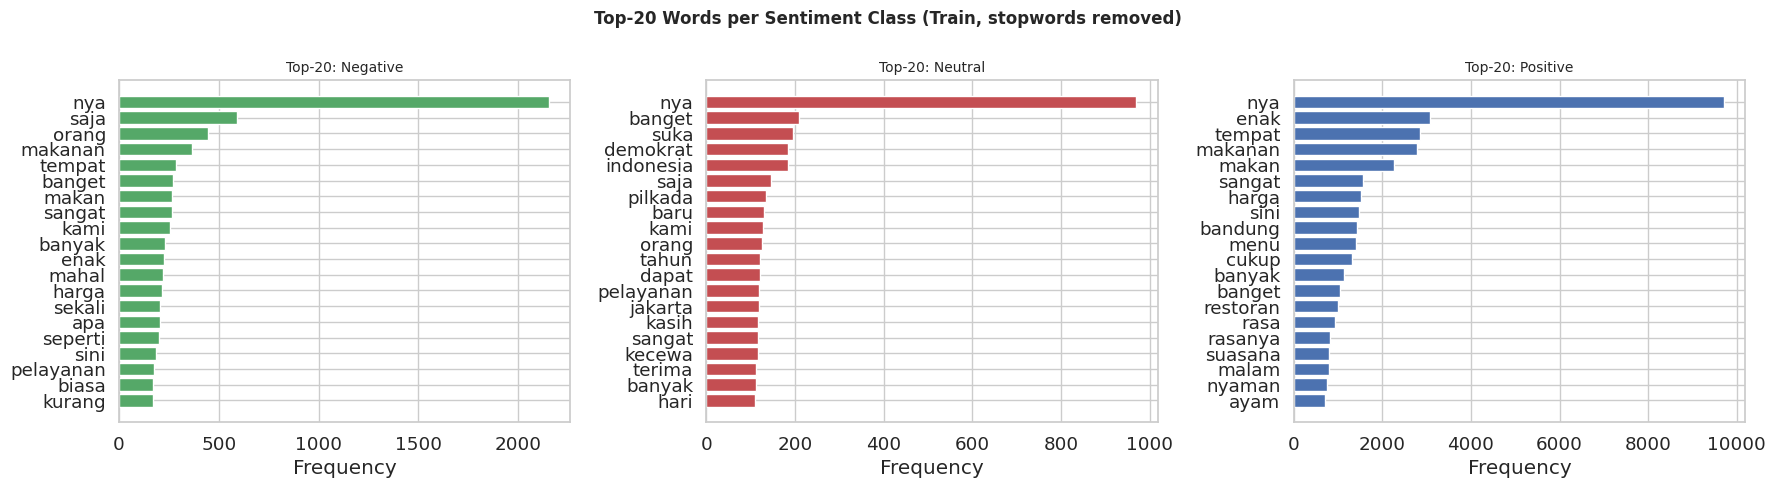

Saved: eda_top_words.png


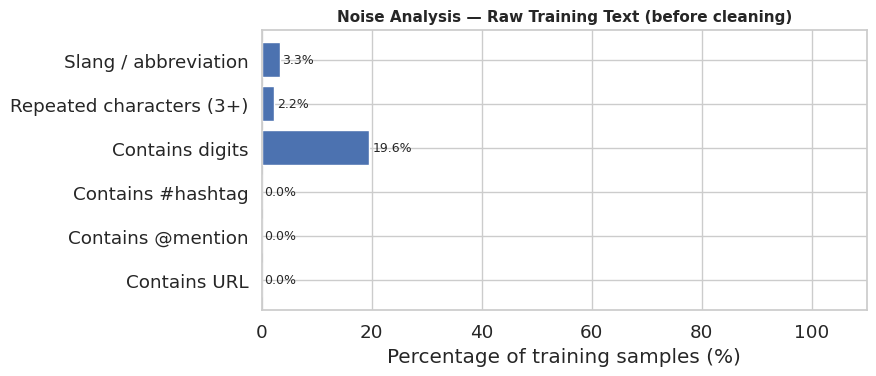

Saved: eda_noise_analysis.png

SUMMARY STATISTICS (post-cleaning)

[TRAIN]
  Total samples  : 11767
  Avg char length: 168.3  (max: 522)
  Avg word count : 27.0  (max: 85)
  positive    :  5687  (48.3%)
  neutral     :  3040  (25.8%)
  negative    :  3040  (25.8%)

[VALIDATION]
  Total samples  : 1267
  Avg char length: 180.0  (max: 537)
  Avg word count : 29.1  (max: 79)
  positive    :   711  (56.1%)
  negative    :   380  (30.0%)
  neutral     :   176  (13.9%)

[TEST]
  Total samples  : 1268
  Avg char length: 174.3  (max: 486)
  Avg word count : 28.0  (max: 78)
  positive    :   711  (56.1%)
  negative    :   380  (30.0%)
  neutral     :   177  (14.0%)

Class imbalance ratio (train): 1.87x  ✓  balanced

Tip: re-run  run_eda(raw_datasets, teacher_tok=teacher_tokenizer)  after Cell 12 to include token-length plots.


In [10]:
# Cell 10: EDA — Exploratory Data Analysis
# ─────────────────────────────────────────────────────────────────────────────
from collections import Counter

STOPWORDS_ID = {
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "dengan", "untuk",
    "pada", "adalah", "atau", "juga", "saya", "tidak", "kamu", "ada",
    "sudah", "akan", "bisa", "lagi", "dalam", "karena", "lebih", "tapi",
    "jadi", "kalau", "kita", "mereka", "satu", "dua", "tiga",
    "belum", "sama", "pun", "mau", "sih", "aja", "deh", "lah", "dong",
    "ya", "iya", "oh", "ah", "hm", "nih", "kan", "yah",
}


def run_eda(datasets: DatasetDict, teacher_tok=None):
    splits     = ["train", "validation", "test"]
    all_lbls   = sorted(set(datasets["train"]["label"]))
    palette    = ["#55A868", "#C44E52", "#4C72B0", "#DD8452", "#8172B2"]
    lbl_colors = {l: palette[i % len(palette)] for i, l in enumerate(all_lbls)}

    all_dfs = {}
    for split in splits:
        df              = pd.DataFrame(datasets[split])
        df["text_len"]  = df["text"].str.len()
        df["word_count"]= df["text"].str.split().str.len()
        if teacher_tok is not None:
            df["token_count"] = df["text"].apply(
                lambda t: len(teacher_tok.encode(t, add_special_tokens=True))
            )
        all_dfs[split] = df

    # Fig 1: Label distribution + char length + word count
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    fig.suptitle(f"EDA — Indonesian Sentiment | Dataset: alvinhanafie",
                 fontsize=14, fontweight="bold")

    for idx, split in enumerate(splits):
        df     = all_dfs[split]
        counts = df["label"].value_counts().sort_index()
        bar_c  = [lbl_colors.get(l, "#999") for l in counts.index]
        bars   = axes[0][idx].bar(counts.index, counts.values, color=bar_c, edgecolor="white")
        for bar, val in zip(bars, counts.values):
            axes[0][idx].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                              str(val), ha="center", va="bottom", fontsize=9)
        axes[0][idx].set_title(f"Labels — {split.capitalize()}", fontsize=9)
        axes[0][idx].set_xlabel("Label")
        axes[0][idx].set_ylabel("Count")

    for idx, split in enumerate(splits):
        df = all_dfs[split]
        for lbl, color in lbl_colors.items():
            sub = df[df["label"] == lbl]["text_len"]
            if len(sub):
                axes[1][idx].hist(sub, bins=40, alpha=0.6, color=color, label=lbl)
        axes[1][idx].set_title(f"Char Length — {split.capitalize()}", fontsize=9)
        axes[1][idx].set_xlabel("Characters")
        axes[1][idx].set_ylabel("Frequency")
        axes[1][idx].legend(fontsize=7)

    for idx, split in enumerate(splits):
        df = all_dfs[split]
        for lbl, color in lbl_colors.items():
            sub = df[df["label"] == lbl]["word_count"]
            if len(sub):
                axes[2][idx].hist(sub, bins=30, alpha=0.6, color=color, label=lbl)
        axes[2][idx].set_title(f"Word Count — {split.capitalize()}", fontsize=9)
        axes[2][idx].set_xlabel("Words")
        axes[2][idx].set_ylabel("Frequency")
        axes[2][idx].legend(fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(OUTPUT_DIR, "eda_overview.png"), dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: eda_overview.png")

    # Fig 2: Token-length distribution
    if teacher_tok is not None:
        fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
        fig2.suptitle(f"Token Length After IndoBERT Tokenisation (MAX_LENGTH = {MAX_LENGTH})",
                      fontsize=12, fontweight="bold")
        for idx, split in enumerate(splits):
            df = all_dfs[split]
            for lbl, color in lbl_colors.items():
                sub = df[df["label"] == lbl]["token_count"]
                if len(sub):
                    axes2[idx].hist(sub, bins=30, alpha=0.6, color=color, label=lbl)
            axes2[idx].axvline(MAX_LENGTH, color="red", linestyle="--", linewidth=1.2,
                               label="truncation boundary")
            pct = (df["token_count"] > MAX_LENGTH).mean() * 100
            axes2[idx].set_title(f"{split.capitalize()} — truncated: {pct:.1f}%", fontsize=9)
            axes2[idx].set_xlabel("Tokens")
            axes2[idx].set_ylabel("Frequency")
            axes2[idx].legend(fontsize=7)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "eda_token_length.png"), dpi=120)
        plt.show()
        print("Saved: eda_token_length.png")

    # Fig 3: Top-20 words per sentiment class
    fig3, axes3 = plt.subplots(1, len(all_lbls), figsize=(6 * len(all_lbls), 5))
    if len(all_lbls) == 1:
        axes3 = [axes3]
    fig3.suptitle("Top-20 Words per Sentiment Class (Train, stopwords removed)",
                  fontsize=12, fontweight="bold")
    train_df = all_dfs["train"]
    for idx, lbl in enumerate(all_lbls):
        color = lbl_colors.get(lbl, "#4C72B0")
        words = [
            w for s in train_df[train_df["label"] == lbl]["text"]
            for w in s.split()
            if w not in STOPWORDS_ID and len(w) > 2
        ]
        top20 = Counter(words).most_common(20)
        if top20:
            ws, fs = zip(*top20)
            axes3[idx].barh(list(ws)[::-1], list(fs)[::-1], color=color, edgecolor="white")
        axes3[idx].set_title(f"Top-20: {lbl.capitalize()}", fontsize=10)
        axes3[idx].set_xlabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "eda_top_words.png"), dpi=120)
    plt.show()
    print("Saved: eda_top_words.png")

    # Fig 4: Noise analysis
    if "raw_text" in all_dfs["train"].columns:
        raw_col  = all_dfs["train"]["raw_text"]
        slang_pat = r"\b(" + "|".join(
            re.escape(k) for k in list(SLANG_DICT.keys())[:40]
        ) + r")\b"
        noise_stats = {
            "Contains URL"             : raw_col.str.contains(r"https?://", regex=True, na=False).mean(),
            "Contains @mention"        : raw_col.str.contains(r"@\w+",    regex=True, na=False).mean(),
            "Contains #hashtag"        : raw_col.str.contains(r"#\w+",    regex=True, na=False).mean(),
            "Contains digits"          : raw_col.str.contains(r"\d",      regex=True, na=False).mean(),
            "Repeated characters (3+)" : raw_col.str.contains(r"(.)\1{2,}",regex=True, na=False).mean(),
            "Slang / abbreviation"     : raw_col.str.lower().str.contains(slang_pat, regex=True, na=False).mean(),
        }
        fig4, ax4 = plt.subplots(figsize=(9, 4))
        labels_n = list(noise_stats.keys())
        values_n = [v * 100 for v in noise_stats.values()]
        bars_n   = ax4.barh(labels_n, values_n, color="#4C72B0", edgecolor="white")
        for bar, val in zip(bars_n, values_n):
            ax4.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=9)
        ax4.set_xlim(0, 110)
        ax4.set_xlabel("Percentage of training samples (%)")
        ax4.set_title("Noise Analysis — Raw Training Text (before cleaning)",
                      fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "eda_noise_analysis.png"), dpi=120)
        plt.show()
        print("Saved: eda_noise_analysis.png")

    # Summary statistics
    print("\n" + "=" * 62)
    print("SUMMARY STATISTICS (post-cleaning)")
    print("=" * 62)
    for split in splits:
        df = all_dfs[split]
        print(f"\n[{split.upper()}]")
        print(f"  Total samples  : {len(df)}")
        print(f"  Avg char length: {df['text_len'].mean():.1f}  (max: {df['text_len'].max()})")
        print(f"  Avg word count : {df['word_count'].mean():.1f}  (max: {df['word_count'].max()})")
        if teacher_tok is not None and "token_count" in df.columns:
            pct = (df["token_count"] > MAX_LENGTH).mean() * 100
            print(f"  Avg token count: {df['token_count'].mean():.1f}  (>{MAX_LENGTH}: {pct:.1f}%)")
        for lbl, cnt in df["label"].value_counts().items():
            print(f"  {lbl:<12}: {cnt:>5}  ({cnt / len(df) * 100:.1f}%)")

    dist  = all_dfs["train"]["label"].value_counts()
    ratio = dist.max() / dist.min()
    print(f"\nClass imbalance ratio (train): {ratio:.2f}x  "
          f"{'⚠  imbalanced' if ratio > 2 else '✓  balanced'}")


run_eda(raw_datasets, teacher_tok=None)
print("\nTip: re-run  run_eda(raw_datasets, teacher_tok=teacher_tokenizer)  after Cell 12 "
      "to include token-length plots.")


In [11]:
# Cell 11: Label encoding — map string labels to integer class indices
# ─────────────────────────────────────────────────────────────────────────────
# Sorted alphabetically: negative→0, neutral→1, positive→2 (for 3 classes)
# For 2 classes (positive/negative): negative→0, positive→1
all_labels = sorted({lbl for split in raw_datasets.values() for lbl in split["label"]})
label2id   = {l: i for i, l in enumerate(all_labels)}
id2label   = {i: l for i, l in enumerate(all_labels)}
num_labels = len(all_labels)

print(f"Labels ({num_labels}) : {all_labels}")
print(f"label2id             : {label2id}")


def encode_labels(example: dict) -> dict:
    example["label"] = label2id[example["label"]]
    return example


raw_datasets = raw_datasets.map(encode_labels)
print("✓ Label encoding done.")


Labels (3) : ['negative', 'neutral', 'positive']
label2id             : {'negative': 0, 'neutral': 1, 'positive': 2}


Map:   0%|          | 0/11767 [00:00<?, ? examples/s]

Map:   0%|          | 0/1267 [00:00<?, ? examples/s]

Map:   0%|          | 0/1268 [00:00<?, ? examples/s]

✓ Label encoding done.


In [12]:
# Cell 12: Load tokenizers
# ─────────────────────────────────────────────────────────────────────────────
teacher_tokenizer = AutoTokenizer.from_pretrained(TEACHER_NAME)
student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_NAME)

print(f"Teacher tokenizer : {TEACHER_NAME}  (vocab: {teacher_tokenizer.vocab_size:,})")
print(f"Student tokenizer : {STUDENT_NAME}  (vocab: {student_tokenizer.vocab_size:,})")

_test = "saya suka makan nasi goreng"
t_ids = teacher_tokenizer(_test)["input_ids"]
s_ids = student_tokenizer(_test)["input_ids"]
print(f"\nTest sentence : '{_test}'")
print(f"  Teacher IDs : {t_ids}")
print(f"  Student IDs : {s_ids}")

assert teacher_tokenizer.vocab_size != student_tokenizer.vocab_size, \
    "Vocab sizes are identical — did you accidentally load the same model twice?"
assert t_ids != s_ids, \
    "Token IDs are identical — tokenizers are not genuinely different models."
print("\n✓ Tokenizers verified — genuinely different vocabularies.")


Teacher tokenizer : indobenchmark/indobert-base-p1  (vocab: 30,521)
Student tokenizer : distilbert-base-multilingual-cased  (vocab: 119,547)

Test sentence : 'saya suka makan nasi goreng'
  Teacher IDs : [2, 209, 1506, 521, 3210, 5259, 3]
  Student IDs : [101, 64981, 10198, 10371, 76306, 12947, 10116, 11783, 67398, 102]

✓ Tokenizers verified — genuinely different vocabularies.


In [13]:
# Cell 13: Tokenise datasets for standalone teacher/student training
# ─────────────────────────────────────────────────────────────────────────────
def tokenize_fn(examples: dict, tokenizer) -> dict:
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )


# Drop raw_text column if it exists
def _get_remove_cols(ds):
    return [c for c in ["text", "raw_text"] if c in ds.column_names]


teacher_datasets = raw_datasets.map(
    lambda x: tokenize_fn(x, teacher_tokenizer),
    batched=True,
    remove_columns=_get_remove_cols(raw_datasets["train"]),
    desc="Tokenising (teacher)",
)
student_datasets = raw_datasets.map(
    lambda x: tokenize_fn(x, student_tokenizer),
    batched=True,
    remove_columns=_get_remove_cols(raw_datasets["train"]),
    desc="Tokenising (student)",
)

print("Teacher dataset columns:", teacher_datasets["train"].column_names)
print("Student dataset columns:", student_datasets["train"].column_names)


Tokenising (teacher):   0%|          | 0/11767 [00:00<?, ? examples/s]

Tokenising (teacher):   0%|          | 0/1267 [00:00<?, ? examples/s]

Tokenising (teacher):   0%|          | 0/1268 [00:00<?, ? examples/s]

Tokenising (student):   0%|          | 0/11767 [00:00<?, ? examples/s]

Tokenising (student):   0%|          | 0/1267 [00:00<?, ? examples/s]

Tokenising (student):   0%|          | 0/1268 [00:00<?, ? examples/s]

Teacher dataset columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Student dataset columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [14]:
# Cell 14: Dual-tokenise for Knowledge Distillation
# ─────────────────────────────────────────────────────────────────────────────
def preprocess_function(examples: dict) -> dict:
    student_enc = student_tokenizer(
        examples["text"], max_length=MAX_LENGTH, truncation=True, padding=False,
    )
    teacher_enc = teacher_tokenizer(
        examples["text"], max_length=MAX_LENGTH, truncation=True, padding=False,
    )
    teacher_tti = teacher_enc.get(
        "token_type_ids",
        [[0] * len(ids) for ids in teacher_enc["input_ids"]],
    )
    return {
        "input_ids":              student_enc["input_ids"],
        "attention_mask":         student_enc["attention_mask"],
        "teacher_input_ids":      teacher_enc["input_ids"],
        "teacher_attention_mask": teacher_enc["attention_mask"],
        "teacher_token_type_ids": teacher_tti,
        "label":                  examples["label"],
    }


KEEP_COLS = {
    "input_ids", "attention_mask",
    "teacher_input_ids", "teacher_attention_mask", "teacher_token_type_ids",
    "label",
}

kd_datasets = raw_datasets.map(
    preprocess_function,
    batched=True,
    load_from_cache_file=False,
    remove_columns=[c for c in raw_datasets["train"].column_names if c not in KEEP_COLS],
    desc="Dual-tokenising for KD",
)
kd_datasets.set_format("torch")

kd_train_dataset = kd_datasets["train"]
kd_valid_dataset = kd_datasets["validation"]
kd_test_dataset  = kd_datasets["test"]

print("KD dataset columns :", kd_train_dataset.column_names)
print(f"Train  : {len(kd_train_dataset)}")
print(f"Valid  : {len(kd_valid_dataset)}")
print(f"Test   : {len(kd_test_dataset)}")


Dual-tokenising for KD:   0%|          | 0/11767 [00:00<?, ? examples/s]

Dual-tokenising for KD:   0%|          | 0/1267 [00:00<?, ? examples/s]

Dual-tokenising for KD:   0%|          | 0/1268 [00:00<?, ? examples/s]

KD dataset columns : ['label', 'input_ids', 'attention_mask', 'teacher_input_ids', 'teacher_attention_mask', 'teacher_token_type_ids']
Train  : 11767
Valid  : 1267
Test   : 1268


In [15]:
# Cell 15: KDDataCollator — batching for dual-tokenised KD datasets
# ─────────────────────────────────────────────────────────────────────────────
@dataclass
class KDDataCollator:
    student_tokenizer: Any
    teacher_tokenizer: Any

    def __call__(self, features: list) -> dict:
        def to_list(v):
            return v.tolist() if isinstance(v, torch.Tensor) else list(v)

        student_feats = [
            {"input_ids":      to_list(f["input_ids"]),
             "attention_mask": to_list(f["attention_mask"])}
            for f in features
        ]
        teacher_feats = [
            {"input_ids":      to_list(f["teacher_input_ids"]),
             "attention_mask": to_list(f["teacher_attention_mask"]),
             "token_type_ids": to_list(f["teacher_token_type_ids"])}
            for f in features
        ]
        labels = torch.tensor([int(f["label"]) for f in features], dtype=torch.long)

        s_batch = self.student_tokenizer.pad(student_feats, padding=True, return_tensors="pt")
        t_batch = self.teacher_tokenizer.pad(teacher_feats, padding=True, return_tensors="pt")

        return {
            "input_ids":              s_batch["input_ids"],
            "attention_mask":         s_batch["attention_mask"],
            "teacher_input_ids":      t_batch["input_ids"],
            "teacher_attention_mask": t_batch["attention_mask"],
            "teacher_token_type_ids": t_batch["token_type_ids"],
            "labels":                 labels,
        }


kd_data_collator = KDDataCollator(
    student_tokenizer=student_tokenizer,
    teacher_tokenizer=teacher_tokenizer,
)
print("✓ KDDataCollator ready.")


✓ KDDataCollator ready.


In [16]:
# Cell 16: Optional class weights
# ─────────────────────────────────────────────────────────────────────────────
def get_class_weights(dataset) -> torch.Tensor:
    y = np.array(dataset["label"])
    w = compute_class_weight("balanced", classes=np.unique(y), y=y)
    return torch.tensor(w, dtype=torch.float)


CLASS_WEIGHTS = get_class_weights(teacher_datasets["train"]) if USE_CLASS_WEIGHT else None

if CLASS_WEIGHTS is not None:
    print(f"Class weights: {dict(zip(all_labels, CLASS_WEIGHTS.numpy().round(4)))}")
else:
    print("Class weights: disabled  (USE_CLASS_WEIGHT=False)")
    print("Tip: Set USE_CLASS_WEIGHT=True in Cell 4 if your dataset is imbalanced.")


Class weights: {'negative': np.float32(1.2902), 'neutral': np.float32(1.2902), 'positive': np.float32(0.6897)}


In [17]:
# Cell 17: Evaluation metrics
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(eval_pred: EvalPrediction) -> dict:
    logits, labels = eval_pred
    preds    = np.argmax(logits, axis=-1)
    macro_f1 = sk_f1(labels, preds, average="macro", zero_division=0)
    report   = classification_report(
        labels, preds, target_names=all_labels, zero_division=0,
    )
    return {"f1": macro_f1, "report": report}


In [18]:
# Cell 18: MetricsLoggerCallback — per-epoch history for post-training plots
# ─────────────────────────────────────────────────────────────────────────────
class MetricsLoggerCallback(TrainerCallback):

    def __init__(self, model_name: str):
        self.model_name       = model_name
        self._last_train_loss = None
        self.history          = {"epoch": [], "train_loss": [], "eval_loss": [], "eval_f1": []}

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self._last_train_loss = logs["loss"]

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return
        epoch = int(math.ceil(state.epoch))
        tl    = self._last_train_loss
        el    = metrics.get("eval_loss")
        f1    = metrics.get("eval_f1")
        self.history["epoch"].append(epoch)
        self.history["train_loss"].append(tl)
        self.history["eval_loss"].append(el)
        self.history["eval_f1"].append(f1)
        tl_str = f"{tl:.4f}" if tl is not None else "N/A"
        el_str = f"{el:.4f}" if el is not None else "N/A"
        f1_str = f"{f1:.4f}" if f1 is not None else "N/A"
        print(
            f"  [{self.model_name}] Epoch {epoch:>2} | "
            f"train_loss: {tl_str:>7} | "
            f"eval_loss: {el_str:>7} | "
            f"eval_F1: {f1_str:>7}"
        )


teacher_cb = MetricsLoggerCallback("Teacher")
sd_cb      = MetricsLoggerCallback("Self-Distilled-Teacher")
no_kd_cb   = MetricsLoggerCallback("Student-no-KD")
kd_cb      = MetricsLoggerCallback("Student-with-KD")
print("✓ Callbacks ready.")


✓ Callbacks ready.


In [19]:
# Cell 19: TrainingArguments factory
# ─────────────────────────────────────────────────────────────────────────────
def make_training_args(output_dir: str, lr: float) -> TrainingArguments:
    return TrainingArguments(
        output_dir                  = output_dir,
        num_train_epochs            = NUM_EPOCHS,
        per_device_train_batch_size = TRAIN_BATCH_SIZE,
        per_device_eval_batch_size  = EVAL_BATCH_SIZE,
        learning_rate               = lr,
        weight_decay                = WEIGHT_DECAY,
        warmup_ratio                = WARMUP_RATIO,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "eval_f1",
        greater_is_better           = True,
        save_total_limit            = 2,
        logging_steps               = 50,
        report_to                   = "none",
        fp16                        = (DEVICE_TYPE == "gpu"),
        remove_unused_columns       = False,
    )


print("✓ make_training_args defined.")


✓ make_training_args defined.


In [20]:
# Cell 20: _filter_model_inputs helper
# ─────────────────────────────────────────────────────────────────────────────
def _filter_model_inputs(model: nn.Module, inputs: dict) -> dict:
    always_exclude = {
        "teacher_input_ids", "teacher_attention_mask",
        "teacher_token_type_ids", "labels",
    }
    accepted = set(inspect.signature(model.forward).parameters.keys())
    return {k: v for k, v in inputs.items() if k not in always_exclude and k in accepted}


print("✓ _filter_model_inputs defined.")


✓ _filter_model_inputs defined.


In [21]:
# Cell 21: SelfDistillTrainer
# ─────────────────────────────────────────────────────────────────────────────
class SelfDistillTrainer(Trainer):

    def __init__(self, frozen_teacher, *args,
                 temperature=SD_TEMPERATURE, alpha=SD_ALPHA, **kwargs):
        super().__init__(*args, **kwargs)
        self.frozen_teacher = frozen_teacher.eval()
        self.temperature    = temperature
        self.alpha          = alpha

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        # Unwrap DataParallel if present so signature inspection works correctly
        raw_model   = model.module if hasattr(model, "module") else model
        raw_teacher = (
            self.frozen_teacher.module
            if hasattr(self.frozen_teacher, "module")
            else self.frozen_teacher
        )

        student_inputs = {
            k: v for k, v in inputs.items()
            if k in set(inspect.signature(raw_model.forward).parameters)
            and k not in {"labels"}
        }
        student_out = model(**student_inputs, output_hidden_states=False)

        teacher_inputs = {
            k: v for k, v in inputs.items()
            if k in set(inspect.signature(raw_teacher.forward).parameters)
            and k not in {"labels"}
        }
        with torch.no_grad():
            teacher_out = self.frozen_teacher(**teacher_inputs, output_hidden_states=False)

        T       = self.temperature
        loss_ce = F.cross_entropy(student_out.logits, labels)
        loss_kl = F.kl_div(
            F.log_softmax(student_out.logits / T, dim=-1),
            F.softmax(teacher_out.logits  / T, dim=-1),
            reduction="batchmean",
        ) * (T ** 2)
        loss = (1 - self.alpha) * loss_ce + self.alpha * loss_kl
        return (loss, student_out) if return_outputs else loss


In [22]:
# Cell 22: VanillaKDTrainer — Knowledge Distillation (KL + CE)
# ─────────────────────────────────────────────────────────────────────────────
# Vanilla KD loss (Hinton et al., 2015):
#
#   L = (1 - α) * L_CE(student_logits, hard_labels)
#     +  α      * T² * KL(softmax(s/T) || softmax(t/T))
#
# No hidden-state matching, no attention transfer, no projection layers.
# Only logit-level distillation from teacher → student.

class VanillaKDTrainer(Trainer):
    """
    Vanilla Knowledge Distillation (Hinton et al., 2015).

    Loss formula:
        L_train = (1 - α) * L_CE_smooth(student, hard_labels)
                +  α      * T² * KL( softmax(s/T) || softmax(t/T) )

        L_eval  = L_CE_smooth(student, hard_labels)   ← CE only, no KD

    Fix notes vs original:
    - label_smoothing dan class_weights dipisah dengan benar:
        * class_weights masuk ke CE sebagai loss re-weighting per kelas
        * label_smoothing diterapkan terpisah via smooth_one_hot agar tidak
          berinteraksi buruk dengan class_weights di F.cross_entropy
    - eval loss menggunakan CE murni (tanpa T² scaling) agar angka yang
      dilaporkan Trainer dapat dibandingkan dengan baseline no-KD secara fair
    - KL loss di-clamp ke >= 0 untuk mencegah numerik negatif yang kadang
      muncul akibat floating-point di batchmean reduction
    """

    def __init__(
        self, teacher_model, *args,
        alpha=KD_ALPHA,
        temperature=KD_TEMPERATURE,
        class_weights=None,
        label_smoothing=LABEL_SMOOTHING,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self.teacher         = teacher_model.eval()
        self.alpha           = alpha
        self.temperature     = temperature
        self.class_weights   = class_weights
        self.label_smoothing = label_smoothing
        self._student_keys   = (
            set(inspect.signature(self.model.forward).parameters)
            - {"teacher_input_ids", "teacher_attention_mask",
               "teacher_token_type_ids", "labels"}
        )

    # ── Helper: CE dengan class_weights dan label_smoothing yang benar ────────
    def _ce_loss(self, logits: torch.Tensor, labels: torch.Tensor,
                 dev: torch.device) -> torch.Tensor:
        """
        Proper CE + label smoothing + class weighting.
        PyTorch F.cross_entropy dengan weight + label_smoothing kadang
        menghasilkan magnitude yang tidak stabil karena smoothing di-apply
        setelah per-sample weight. Kita hitung manual via log_softmax agar
        urutan operasi eksplisit dan deterministik.
        """
        num_classes = logits.size(-1)
        ls          = self.label_smoothing

        # Smooth one-hot: (1 - ls) * one_hot + ls / C
        with torch.no_grad():
            smooth_labels = torch.full_like(
                logits, ls / num_classes
            )
            smooth_labels.scatter_(1, labels.to(dev).unsqueeze(1),
                                   (1.0 - ls) + ls / num_classes)

        log_probs = F.log_softmax(logits, dim=-1)               # (B, C)
        loss_per_sample = -(smooth_labels * log_probs).sum(-1)  # (B,)

        if self.class_weights is not None:
            w = self.class_weights.to(dev)[labels.to(dev)]      # (B,)
            loss_per_sample = loss_per_sample * w
            return loss_per_sample.sum() / w.sum()              # weighted mean
        return loss_per_sample.mean()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels                 = inputs["labels"]
        teacher_input_ids      = inputs.get("teacher_input_ids")
        teacher_attention_mask = inputs.get("teacher_attention_mask")
        teacher_token_type_ids = inputs.get("teacher_token_type_ids")
        is_training            = model.training

        # ── Student forward pass ───────────────────────────────────────────────
        student_inputs = {k: v for k, v in inputs.items() if k in self._student_keys}
        student_out    = model(**student_inputs)
        dev            = student_out.logits.device

        # ── Hard-label CE loss (dengan label smoothing + class weights) ────────
        loss_ce = self._ce_loss(student_out.logits, labels, dev)

        # ── Eval: CE only, no KD (loss yang dilaporkan Trainer = comparable) ───
        if not is_training:
            return (loss_ce, student_out) if return_outputs else loss_ce

        # ── Teacher forward pass (no grad) ─────────────────────────────────────
        with torch.no_grad():
            t_kwargs = dict(
                input_ids      = teacher_input_ids.to(dev),
                attention_mask = teacher_attention_mask.to(dev),
            )
            if teacher_token_type_ids is not None:
                t_kwargs["token_type_ids"] = teacher_token_type_ids.to(dev)
            teacher_out = self.teacher(**t_kwargs)

        # ── Soft-target KL divergence (Hinton 2015) ────────────────────────────
        T       = self.temperature
        s_soft  = F.log_softmax(student_out.logits / T, dim=-1)
        t_soft  = F.softmax(teacher_out.logits     / T, dim=-1)
        loss_kl = F.kl_div(s_soft, t_soft, reduction="batchmean") * (T ** 2)
        loss_kl = loss_kl.clamp(min=0.0)   # guard against fp16 rounding

        # ── Combined KD loss ───────────────────────────────────────────────────
        # Total weights sum to 1.0: (1-α) + α = 1
        loss = (1.0 - self.alpha) * loss_ce + self.alpha * loss_kl

        return (loss, student_out) if return_outputs else loss


print("✓ VanillaKDTrainer defined.")
print(f"  Loss = (1-α)*CE_smooth + α*T²*KL")
print(f"  α={KD_ALPHA}, T={KD_TEMPERATURE}, label_smoothing={LABEL_SMOOTHING}")


✓ VanillaKDTrainer defined.
  Loss = (1-α)*CE_smooth + α*T²*KL
  α=0.5, T=2.0, label_smoothing=0.1


In [23]:
# Cell 23: Sanity check — KD dataset columns dan collator output shape
# ─────────────────────────────────────────────────────────────────────────────
required_cols = [
    "input_ids", "attention_mask",
    "teacher_input_ids", "teacher_attention_mask", "teacher_token_type_ids",
    "label",
]
for col in required_cols:
    assert col in kd_train_dataset.column_names, f"Missing column: {col}"
print("✓ All required columns present:", kd_train_dataset.column_names)

sample = kd_train_dataset[0]
print(f"\nSample — student tokens : {len(sample['input_ids'])}")
print(f"Sample — teacher tokens : {len(sample['teacher_input_ids'])}")
print(f"Sample — label          : {sample['label']} → {id2label[int(sample['label'])]}")

try:
    batch = kd_data_collator([kd_train_dataset[0], kd_train_dataset[1]])
    print("\n✓ Collator smoke-test passed")
    print(f"  student input_ids shape : {batch['input_ids'].shape}")
    print(f"  teacher input_ids shape : {batch['teacher_input_ids'].shape}")
    print(f"  labels shape            : {batch['labels'].shape}")
except Exception as e:
    print(f"\n✗ Collator smoke-test FAILED: {e}")
    raise
finally:
    kd_datasets.set_format("torch")
    kd_train_dataset = kd_datasets["train"]
    kd_valid_dataset = kd_datasets["validation"]
    kd_test_dataset  = kd_datasets["test"]


✓ All required columns present: ['label', 'input_ids', 'attention_mask', 'teacher_input_ids', 'teacher_attention_mask', 'teacher_token_type_ids']

Sample — student tokens : 22
Sample — teacher tokens : 19
Sample — label          : 1 → neutral

✓ Collator smoke-test passed
  student input_ids shape : torch.Size([2, 22])
  teacher input_ids shape : torch.Size([2, 19])
  labels shape            : torch.Size([2])


In [24]:
# Cell 24: Train teacher model — indobenchmark/indobert-base-p1
# ─────────────────────────────────────────────────────────────────────────────
teacher_model = AutoModelForSequenceClassification.from_pretrained(
    TEACHER_NAME,
    num_labels=num_labels, id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True,
)

teacher_trainer = Trainer(
    model            = teacher_model,
    args             = make_training_args(os.path.join(OUTPUT_DIR, "ckpt-teacher"), TEACHER_LR),
    train_dataset    = teacher_datasets["train"],
    eval_dataset     = teacher_datasets["validation"],
    processing_class = teacher_tokenizer,
    data_collator    = DataCollatorWithPadding(teacher_tokenizer),
    compute_metrics  = compute_metrics,
    callbacks        = [teacher_cb, EarlyStoppingCallback(EARLY_STOPPING_PATIENCE)],
)

teacher_trainer.train()
teacher_results = teacher_trainer.evaluate(teacher_datasets["test"])

print(f"\nTeacher  —  Test F1   : {teacher_results['eval_f1']:.4f}")
print(f"Teacher  —  Test Loss : {teacher_results['eval_loss']:.4f}")
print("\nClassification Report (Teacher):")
print(teacher_results.get("eval_report", ""))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1,Report
1,0.529501,0.488862,0.874284,precision recall f1-score support negative 0.90 0.87 0.88 380 neutral 0.82 0.77 0.79 176 positive 0.93 0.97 0.95 711 accuracy 0.91 1267 macro avg 0.88 0.87 0.87 1267 weighted avg 0.91 0.91 0.91 1267
2,0.295313,0.571088,0.883159,precision recall f1-score support negative 0.89 0.89 0.89 380 neutral 0.84 0.78 0.81 176 positive 0.94 0.95 0.95 711 accuracy 0.91 1267 macro avg 0.89 0.88 0.88 1267 weighted avg 0.91 0.91 0.91 1267
3,0.186042,0.771743,0.877765,precision recall f1-score support negative 0.86 0.92 0.89 380 neutral 0.86 0.75 0.80 176 positive 0.95 0.94 0.94 711 accuracy 0.91 1267 macro avg 0.89 0.87 0.88 1267 weighted avg 0.91 0.91 0.91 1267
4,0.028774,1.015038,0.885329,precision recall f1-score support negative 0.86 0.93 0.90 380 neutral 0.90 0.74 0.81 176 positive 0.95 0.95 0.95 711 accuracy 0.91 1267 macro avg 0.90 0.87 0.89 1267 weighted avg 0.91 0.91 0.91 1267
5,0.021738,1.085932,0.883744,precision recall f1-score support negative 0.87 0.93 0.90 380 neutral 0.90 0.73 0.81 176 positive 0.94 0.95 0.95 711 accuracy 0.91 1267 macro avg 0.90 0.87 0.88 1267 weighted avg 0.91 0.91 0.91 1267


  [Teacher] Epoch  1 | train_loss:  0.5295 | eval_loss:  0.4889 | eval_F1:  0.8743


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Teacher] Epoch  5 | train_loss:  0.0217 | eval_loss:  1.0859 | eval_F1:  0.8837


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  [Teacher] Epoch  5 | train_loss:  0.0217 | eval_loss:  1.0459 | eval_F1:  0.8862

Teacher  —  Test F1   : 0.8862
Teacher  —  Test Loss : 1.0459

Classification Report (Teacher):
              precision    recall  f1-score   support

    negative       0.88      0.91      0.90       380
     neutral       0.85      0.78      0.81       177
    positive       0.95      0.95      0.95       711

    accuracy                           0.92      1268
   macro avg       0.89      0.88      0.89      1268
weighted avg       0.92      0.92      0.92      1268



In [25]:
# Cell CV-1: Stratified K-Fold Cross-Validation (sebelum full training)
# ─────────────────────────────────────────────────────────────────────────────
# Cross-validation dijalankan SEBELUM full training untuk:
#   1. Estimasi generalisasi model yang lebih robust (mean ± std F1 across folds)
#   2. Membuktikan KD gain tidak hanya artifact dari satu split tertentu
#   3. Mendeteksi overfitting lebih awal (gap train-val F1 tiap fold)
#
# CV pool  : df_train + df_val (test tetap held-out, tidak pernah disentuh)
# Fold eval: dilakukan di fold_val (stratified), bukan test set
# Early stopping: aktif di setiap fold (patience = CV_ES_PATIENCE)
# ─────────────────────────────────────────────────────────────────────────────
import gc
from sklearn.model_selection import StratifiedKFold

# ── CV Config (bisa diubah di sini) ──────────────────────────────────────────
N_FOLDS          = 5     # 3 kalau VRAM / waktu terbatas
CV_NUM_EPOCHS    = 3     # Epoch max per fold (early stopping bisa berhenti lebih cepat)
CV_ES_PATIENCE   = 2     # Early stopping patience khusus CV (lebih agresif dari full training)
CV_BATCH_SIZE    = 16
CV_GRAD_ACCUM    = 2     # effective batch = 32
CV_SEED          = RANDOM_SEED

print(f"{'='*66}")
print(f"  Stratified {N_FOLDS}-Fold Cross-Validation")
print(f"  Epochs per fold : {CV_NUM_EPOCHS}  |  ES patience : {CV_ES_PATIENCE}")
print(f"{'='*66}\n")

# ── Gabung train+val → CV pool (test tetap held-out) ─────────────────────────
df_cv_pool    = pd.concat([df_train, df_val], ignore_index=True)
cv_labels_arr = df_cv_pool["label"].map(label2id).values
print(f"CV pool : {len(df_cv_pool)} samples | "
      f"Test (held-out) : {len(df_test)} samples\n")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=CV_SEED)

cv_no_kd_folds = []   # list of {"fold", "f1_macro", "f1_weighted", "best_epoch"}
cv_kd_folds    = []

# ── Helper: buat TrainingArguments untuk CV ───────────────────────────────────
def make_cv_training_args(output_dir: str, lr: float) -> TrainingArguments:
    return TrainingArguments(
        output_dir                  = output_dir,
        num_train_epochs            = CV_NUM_EPOCHS,
        per_device_train_batch_size = CV_BATCH_SIZE,
        per_device_eval_batch_size  = EVAL_BATCH_SIZE,
        gradient_accumulation_steps = CV_GRAD_ACCUM,
        learning_rate               = lr,
        weight_decay                = WEIGHT_DECAY,
        warmup_ratio                = WARMUP_RATIO,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,    # butuh save untuk load_best
        metric_for_best_model       = "eval_f1",
        greater_is_better           = True,
        save_total_limit            = 1,       # hemat disk: hanya simpan 1 ckpt
        logging_steps               = 50,
        report_to                   = "none",
        fp16                        = (DEVICE_TYPE == "gpu"),
        gradient_checkpointing      = True,
        remove_unused_columns       = False,
        dataloader_pin_memory       = False,
    )

# ── Helper: manual eval (bypass Trainer DataParallel) ────────────────────────
def eval_fold_manual(model, dataset, collator, device) -> dict:
    from torch.utils.data import DataLoader
    raw = model.module if hasattr(model, "module") else model
    raw = raw.to(device).eval()
    loader = DataLoader(dataset, batch_size=32, collate_fn=collator)
    all_logits, all_labels_list = [], []
    with torch.no_grad():
        for batch in loader:
            lbls     = batch.pop("labels", None)
            accepted = set(inspect.signature(raw.forward).parameters)
            batch    = {k: v.to(device) for k, v in batch.items() if k in accepted}
            out      = raw(**batch)
            all_logits.append(out.logits.cpu())
            if lbls is not None:
                all_labels_list.append(lbls.cpu())
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels_list).numpy()
    preds  = np.argmax(logits, axis=-1)
    return {
        "f1_macro":    sk_f1(labels, preds, average="macro",    zero_division=0),
        "f1_weighted": sk_f1(labels, preds, average="weighted", zero_division=0),
    }

fold_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ─────────────────────────────────────────────────────────────────────────────
#  K-FOLD LOOP
# ─────────────────────────────────────────────────────────────────────────────
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df_cv_pool, cv_labels_arr)):
    print(f"\n{'─'*60}")
    print(f"  FOLD {fold_idx+1}/{N_FOLDS}   train={len(train_idx)}  val={len(val_idx)}")
    print(f"{'─'*60}")

    fold_train_df = df_cv_pool.iloc[train_idx].reset_index(drop=True)
    fold_val_df   = df_cv_pool.iloc[val_idx].reset_index(drop=True)

    # Class weights per fold
    y_fold = fold_train_df["label"].map(label2id).values
    fold_weights = (
        torch.tensor(
            compute_class_weight("balanced", classes=np.unique(y_fold), y=y_fold),
            dtype=torch.float,
        ) if USE_CLASS_WEIGHT else None
    )

    # HuggingFace Dataset
    fold_raw = DatasetDict({
        "train":      Dataset.from_pandas(fold_train_df, preserve_index=False),
        "validation": Dataset.from_pandas(fold_val_df,   preserve_index=False),
    })
    fold_raw = fold_raw.map(lambda ex: {"label": label2id[ex["label"]]})

    # Tokenise untuk student standalone
    fold_student_ds = fold_raw.map(
        lambda x: tokenize_fn(x, student_tokenizer), batched=True,
        remove_columns=[c for c in ["text","raw_text"] if c in fold_raw["train"].column_names],
    )

    # Dual-tokenise untuk KD
    _kd_keep = {"input_ids","attention_mask","teacher_input_ids",
                "teacher_attention_mask","teacher_token_type_ids","label"}
    fold_kd_ds = fold_raw.map(
        preprocess_function, batched=True, load_from_cache_file=False,
        remove_columns=[c for c in fold_raw["train"].column_names if c not in _kd_keep],
    )
    fold_kd_ds.set_format("torch")

    _kd_collator = KDDataCollator(
        student_tokenizer=student_tokenizer, teacher_tokenizer=teacher_tokenizer
    )

    # ══════════════════════════════════════════════════════════════════════════
    #  (A) Student no-KD  +  Early Stopping
    # ══════════════════════════════════════════════════════════════════════════
    print(f"\n[Fold {fold_idx+1}] ▶ Student no-KD  (max {CV_NUM_EPOCHS} epochs, ES patience={CV_ES_PATIENCE})")
    _no_kd = AutoModelForSequenceClassification.from_pretrained(
        STUDENT_NAME, num_labels=num_labels, id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    )
    _no_kd.gradient_checkpointing_enable()

    _no_kd_trainer = Trainer(
        model            = _no_kd,
        args             = make_cv_training_args(f"/tmp/cv{fold_idx}_no_kd", STUDENT_LR),
        train_dataset    = fold_student_ds["train"],
        eval_dataset     = fold_student_ds["validation"],
        processing_class = student_tokenizer,
        data_collator    = DataCollatorWithPadding(student_tokenizer),
        compute_metrics  = compute_metrics,
        callbacks        = [EarlyStoppingCallback(early_stopping_patience=CV_ES_PATIENCE)],
    )
    _no_kd_trainer.train()
    # best_model_checkpoint formatnya "...checkpoint-STEP", bukan epoch
    # Hitung epoch dari step: steps_per_epoch = ceil(len(train) / effective_batch)
    _steps_per_epoch_no_kd = math.ceil(
        len(fold_student_ds["train"]) / (CV_BATCH_SIZE * CV_GRAD_ACCUM)
    )
    _best_step_no_kd = int(_no_kd_trainer.state.best_model_checkpoint.split("-")[-1])         if _no_kd_trainer.state.best_model_checkpoint else         _steps_per_epoch_no_kd * CV_NUM_EPOCHS
    _best_ep_no_kd = max(1, round(_best_step_no_kd / _steps_per_epoch_no_kd))

    _no_kd_metrics = eval_fold_manual(
        _no_kd, fold_student_ds["validation"],
        DataCollatorWithPadding(student_tokenizer), fold_device,
    )
    cv_no_kd_folds.append({"fold": fold_idx+1, "best_epoch": _best_ep_no_kd, **_no_kd_metrics})
    print(f"  ✓ no-KD  | best_epoch={_best_ep_no_kd} "
          f"| macro-F1={_no_kd_metrics['f1_macro']:.4f} "
          f"| weighted-F1={_no_kd_metrics['f1_weighted']:.4f}")

    del _no_kd, _no_kd_trainer
    gc.collect(); torch.cuda.empty_cache()

    # ══════════════════════════════════════════════════════════════════════════
    #  (B) Student Vanilla KD  +  Early Stopping
    # ══════════════════════════════════════════════════════════════════════════
    print(f"\n[Fold {fold_idx+1}] ▶ Student Vanilla KD  (max {CV_NUM_EPOCHS} epochs, ES patience={CV_ES_PATIENCE})")
    _kd_model = AutoModelForSequenceClassification.from_pretrained(
        STUDENT_NAME, num_labels=num_labels, id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    ).to(fold_device)
    _kd_model.gradient_checkpointing_enable()

    _kd_trainer = VanillaKDTrainer(
        teacher_model    = teacher_model,
        model            = _kd_model,
        args             = make_cv_training_args(f"/tmp/cv{fold_idx}_vanilla_kd", STUDENT_LR),
        alpha            = KD_ALPHA,
        temperature      = KD_TEMPERATURE,
        label_smoothing  = LABEL_SMOOTHING,
        class_weights    = fold_weights,
        train_dataset    = fold_kd_ds["train"],
        eval_dataset     = fold_kd_ds["validation"],
        processing_class = student_tokenizer,
        data_collator    = _kd_collator,
        compute_metrics  = compute_metrics,
        callbacks        = [EarlyStoppingCallback(early_stopping_patience=CV_ES_PATIENCE)],
    )
    _kd_trainer.train()
    _steps_per_epoch_kd = math.ceil(
        len(fold_kd_ds["train"]) / (CV_BATCH_SIZE * CV_GRAD_ACCUM)
    )
    _best_step_kd = int(_kd_trainer.state.best_model_checkpoint.split("-")[-1])         if _kd_trainer.state.best_model_checkpoint else         _steps_per_epoch_kd * CV_NUM_EPOCHS
    _best_ep_kd = max(1, round(_best_step_kd / _steps_per_epoch_kd))

    _kd_metrics = eval_fold_manual(_kd_model, fold_kd_ds["validation"], _kd_collator, fold_device)
    cv_kd_folds.append({"fold": fold_idx+1, "best_epoch": _best_ep_kd, **_kd_metrics})
    print(f"  ✓ Vanilla KD | best_epoch={_best_ep_kd} "
          f"| macro-F1={_kd_metrics['f1_macro']:.4f} "
          f"| weighted-F1={_kd_metrics['f1_weighted']:.4f}")

    del _kd_model, _kd_trainer, _kd_collator
    gc.collect(); torch.cuda.empty_cache()

# ─────────────────────────────────────────────────────────────────────────────
#  CV SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
df_cv_no_kd = pd.DataFrame(cv_no_kd_folds)
df_cv_kd    = pd.DataFrame(cv_kd_folds)

# Hitung rata-rata best_epoch → akan dipakai sebagai referensi NUM_EPOCHS full training
cv_best_epoch_no_kd = int(round(df_cv_no_kd["best_epoch"].mean()))
cv_best_epoch_kd    = int(round(df_cv_kd["best_epoch"].mean()))

print(f"\n{'='*66}")
print(f"  {N_FOLDS}-FOLD CV — STUDENT NO-KD")
print(f"{'='*66}")
print(df_cv_no_kd.to_string(index=False))
print(f"  Mean Macro-F1    : {df_cv_no_kd['f1_macro'].mean():.4f} ± {df_cv_no_kd['f1_macro'].std():.4f}")
print(f"  Mean Weighted-F1 : {df_cv_no_kd['f1_weighted'].mean():.4f} ± {df_cv_no_kd['f1_weighted'].std():.4f}")
print(f"  Avg best epoch   : {cv_best_epoch_no_kd}")

print(f"\n{'='*66}")
print(f"  {N_FOLDS}-FOLD CV — STUDENT VANILLA KD")
print(f"{'='*66}")
print(df_cv_kd.to_string(index=False))
print(f"  Mean Macro-F1    : {df_cv_kd['f1_macro'].mean():.4f} ± {df_cv_kd['f1_macro'].std():.4f}")
print(f"  Mean Weighted-F1 : {df_cv_kd['f1_weighted'].mean():.4f} ± {df_cv_kd['f1_weighted'].std():.4f}")
print(f"  Avg best epoch   : {cv_best_epoch_kd}")

cv_gain = df_cv_kd["f1_macro"].mean() - df_cv_no_kd["f1_macro"].mean()
print(f"\n  Vanilla KD CV gain (macro-F1) : {cv_gain:+.4f}")
print(f"\n✓ Cross-validation done. Full training akan dilanjutkan di cell berikutnya.")
print(f"  Tip: kalau mau pakai CV avg epoch sebagai NUM_EPOCHS,")
print(f"       set NUM_EPOCHS = cv_best_epoch_kd  ({cv_best_epoch_kd}) di Cell 4.")


  Stratified 5-Fold Cross-Validation
  Epochs per fold : 3  |  ES patience : 2

CV pool : 13034 samples | Test (held-out) : 1268 samples


────────────────────────────────────────────────────────────
  FOLD 1/5   train=10427  val=2607
────────────────────────────────────────────────────────────


Map:   0%|          | 0/10427 [00:00<?, ? examples/s]

Map:   0%|          | 0/2607 [00:00<?, ? examples/s]

Map:   0%|          | 0/10427 [00:00<?, ? examples/s]

Map:   0%|          | 0/2607 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


  ✓ Vanilla KD | best_epoch=2 | macro-F1=0.8588 | weighted-F1=0.8705

  5-FOLD CV — STUDENT NO-KD
 fold  best_epoch  f1_macro  f1_weighted
    1           2  0.849645     0.860132
    2           2  0.857539     0.871439
    3           2  0.867397     0.877857
    4           2  0.858076     0.866845
    5           2  0.864307     0.875851
  Mean Macro-F1    : 0.8594 ± 0.0069
  Mean Weighted-F1 : 0.8704 ± 0.0071
  Avg best epoch   : 2

  5-FOLD CV — STUDENT VANILLA KD
 fold  best_epoch  f1_macro  f1_weighted
    1           2  0.849025     0.859660
    2           2  0.854631     0.868191
    3           2  0.868552     0.877803
    4           2  0.862254     0.870394
    5           2  0.858781     0.870490
  Mean Macro-F1    : 0.8586 ± 0.0074
  Mean Weighted-F1 : 0.8693 ± 0.0065
  Avg best epoch   : 2

  Vanilla KD CV gain (macro-F1) : -0.0007

✓ Cross-validation done. Full training akan dilanjutkan di cell berikutnya.
  Tip: kalau mau pakai CV avg epoch sebagai NUM_EPOCHS,
      

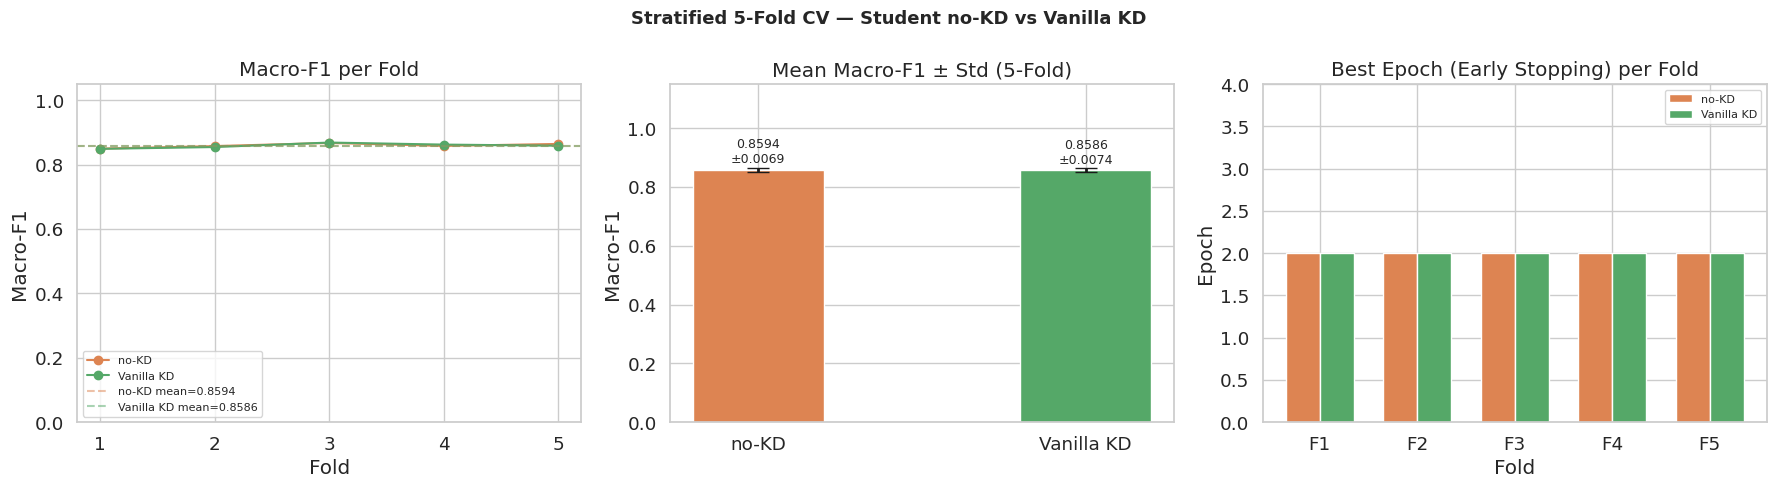

✓ CV visualization saved.


In [26]:
# Cell CV-2: Cross-Validation Visualization
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Stratified {N_FOLDS}-Fold CV — Student no-KD vs Vanilla KD",
             fontsize=13, fontweight="bold")

folds = df_cv_no_kd["fold"].tolist()

# Plot 1: Macro-F1 per fold
ax = axes[0]
ax.plot(folds, df_cv_no_kd["f1_macro"], marker="o", label="no-KD",
        color=COLORS["Student no KD"])
ax.plot(folds, df_cv_kd["f1_macro"], marker="o", label="Vanilla KD",
        color=COLORS["Student with KD"])
ax.axhline(df_cv_no_kd["f1_macro"].mean(), ls="--", color=COLORS["Student no KD"],
           alpha=0.5, label=f"no-KD mean={df_cv_no_kd['f1_macro'].mean():.4f}")
ax.axhline(df_cv_kd["f1_macro"].mean(), ls="--", color=COLORS["Student with KD"],
           alpha=0.5, label=f"Vanilla KD mean={df_cv_kd['f1_macro'].mean():.4f}")
ax.set_title("Macro-F1 per Fold"); ax.set_xlabel("Fold"); ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1.05); ax.set_xticks(folds); ax.legend(fontsize=8)

# Plot 2: Mean ± Std bar chart
ax2 = axes[1]
_models = ["no-KD", "Vanilla KD"]
_means  = [df_cv_no_kd["f1_macro"].mean(), df_cv_kd["f1_macro"].mean()]
_stds   = [df_cv_no_kd["f1_macro"].std(),  df_cv_kd["f1_macro"].std()]
_cols   = [COLORS["Student no KD"], COLORS["Student with KD"]]
_bars   = ax2.bar(_models, _means, yerr=_stds, capsize=8, color=_cols,
                  edgecolor="white", width=0.4, error_kw={"linewidth": 2})
for bar, m, s in zip(_bars, _means, _stds):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.005,
             f"{m:.4f}\n±{s:.4f}", ha="center", va="bottom", fontsize=9)
ax2.set_title(f"Mean Macro-F1 ± Std ({N_FOLDS}-Fold)")
ax2.set_ylabel("Macro-F1"); ax2.set_ylim(0, 1.15)

# Plot 3: Best epoch distribution per fold
ax3 = axes[2]
w = 0.35
x = np.arange(len(folds))
ax3.bar(x - w/2, df_cv_no_kd["best_epoch"], width=w, label="no-KD",
        color=COLORS["Student no KD"], edgecolor="white")
ax3.bar(x + w/2, df_cv_kd["best_epoch"],    width=w, label="Vanilla KD",
        color=COLORS["Student with KD"], edgecolor="white")
ax3.set_title("Best Epoch (Early Stopping) per Fold")
ax3.set_xlabel("Fold"); ax3.set_ylabel("Epoch")
ax3.set_xticks(x); ax3.set_xticklabels([f"F{f}" for f in folds])
ax3.set_ylim(0, CV_NUM_EPOCHS + 1); ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cv_results_vanilla_kd.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ CV visualization saved.")


In [27]:
# Cell 25: Self-distillation (conditional — only runs if teacher F1 < threshold)
# ─────────────────────────────────────────────────────────────────────────────
sd_results = None
sd_trainer  = None

if teacher_results["eval_f1"] < TEACHER_F1_THRESHOLD:
    print(f"Teacher F1 {teacher_results['eval_f1']:.4f} < {TEACHER_F1_THRESHOLD} "
          "→ running self-distillation\n")

    frozen_snapshot    = copy.deepcopy(teacher_model)
    self_distill_model = AutoModelForSequenceClassification.from_pretrained(
        TEACHER_NAME,
        num_labels=num_labels, id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    sd_trainer = SelfDistillTrainer(
        frozen_teacher   = frozen_snapshot,
        model            = self_distill_model,
        args             = make_training_args(os.path.join(OUTPUT_DIR, "ckpt-sd"), TEACHER_LR),
        train_dataset    = teacher_datasets["train"],
        eval_dataset     = teacher_datasets["validation"],
        processing_class = teacher_tokenizer,
        data_collator    = DataCollatorWithPadding(teacher_tokenizer),
        compute_metrics  = compute_metrics,
        callbacks        = [sd_cb, EarlyStoppingCallback(EARLY_STOPPING_PATIENCE)],
    )
    sd_trainer.train()
    sd_results = sd_trainer.evaluate(teacher_datasets["test"])

    print(f"\nOriginal teacher F1       : {teacher_results['eval_f1']:.4f}")
    print(f"Self-distilled teacher F1 : {sd_results['eval_f1']:.4f}")
    print(f"Gain                      : {sd_results['eval_f1'] - teacher_results['eval_f1']:+.4f}")

    if sd_results["eval_f1"] > teacher_results["eval_f1"]:
        print("Self-distilled teacher is better → promoting to final teacher.")
        teacher_model   = self_distill_model
        teacher_results = sd_results
    else:
        print("Original teacher is still better → keeping it.")
else:
    print(f"Teacher F1 {teacher_results['eval_f1']:.4f} ≥ {TEACHER_F1_THRESHOLD} "
          "→ self-distillation skipped.")

print(f"\nFinal teacher F1 : {teacher_results['eval_f1']:.4f}")


Teacher F1 0.8862 ≥ 0.8 → self-distillation skipped.

Final teacher F1 : 0.8862


In [28]:
# Cell 26: Train student baseline — no Knowledge Distillation
# ─────────────────────────────────────────────────────────────────────────────
student_no_kd = AutoModelForSequenceClassification.from_pretrained(
    STUDENT_NAME,
    num_labels=num_labels, id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True,
)

student_no_kd_trainer = Trainer(
    model            = student_no_kd,
    args             = make_training_args(os.path.join(OUTPUT_DIR, "ckpt-student-no-kd"), STUDENT_LR),
    train_dataset    = student_datasets["train"],
    eval_dataset     = student_datasets["validation"],
    processing_class = student_tokenizer,
    data_collator    = DataCollatorWithPadding(student_tokenizer),
    compute_metrics  = compute_metrics,
    callbacks        = [no_kd_cb, EarlyStoppingCallback(EARLY_STOPPING_PATIENCE)],
)

student_no_kd_trainer.train()
no_kd_results = student_no_kd_trainer.evaluate(student_datasets["test"])

print(f"\nStudent (no KD)  —  Test F1   : {no_kd_results['eval_f1']:.4f}")
print(f"Student (no KD)  —  Test Loss : {no_kd_results['eval_loss']:.4f}")
print("\nClassification Report (Student — no KD):")
print(no_kd_results.get("eval_report", ""))


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1,Report
1,0.976959,0.860648,0.790277,precision recall f1-score support negative 0.79 0.75 0.77 380 neutral 0.73 0.68 0.70 176 positive 0.88 0.92 0.90 711 accuracy 0.83 1267 macro avg 0.80 0.78 0.79 1267 weighted avg 0.83 0.83 0.83 1267
2,0.632271,0.767711,0.804325,precision recall f1-score support negative 0.81 0.79 0.80 380 neutral 0.75 0.66 0.70 176 positive 0.89 0.93 0.91 711 accuracy 0.85 1267 macro avg 0.82 0.79 0.80 1267 weighted avg 0.85 0.85 0.85 1267
3,0.344736,0.847945,0.817939,precision recall f1-score support negative 0.79 0.86 0.82 380 neutral 0.82 0.64 0.72 176 positive 0.91 0.92 0.92 711 accuracy 0.86 1267 macro avg 0.84 0.80 0.82 1267 weighted avg 0.86 0.86 0.86 1267
4,0.145656,1.112684,0.822829,precision recall f1-score support negative 0.80 0.87 0.83 380 neutral 0.82 0.64 0.72 176 positive 0.91 0.92 0.92 711 accuracy 0.87 1267 macro avg 0.84 0.81 0.82 1267 weighted avg 0.87 0.87 0.86 1267
5,0.086648,1.210643,0.817077,precision recall f1-score support negative 0.79 0.84 0.82 380 neutral 0.77 0.68 0.72 176 positive 0.92 0.91 0.91 711 accuracy 0.86 1267 macro avg 0.83 0.81 0.82 1267 weighted avg 0.86 0.86 0.86 1267


  [Student-no-KD] Epoch  1 | train_loss:  0.9770 | eval_loss:  0.8606 | eval_F1:  0.7903


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Student-no-KD] Epoch  5 | train_loss:  0.0866 | eval_loss:  1.2106 | eval_F1:  0.8171


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


  [Student-no-KD] Epoch  5 | train_loss:  0.0866 | eval_loss:  1.1704 | eval_F1:  0.8136

Student (no KD)  —  Test F1   : 0.8136
Student (no KD)  —  Test Loss : 1.1704

Classification Report (Student — no KD):
              precision    recall  f1-score   support

    negative       0.78      0.87      0.82       380
     neutral       0.76      0.65      0.70       177
    positive       0.93      0.90      0.92       711

    accuracy                           0.86      1268
   macro avg       0.82      0.81      0.81      1268
weighted avg       0.86      0.86      0.86      1268



In [29]:
# Cell 27: Train student with Vanilla KD
# ─────────────────────────────────────────────────────────────────────────────
import gc

def unwrap_and_pin(model, device="cuda:0"):
    if hasattr(model, "module"):
        model = model.module
    return model.to(device)

teacher_model = unwrap_and_pin(teacher_model.eval())

gc.collect()
torch.cuda.empty_cache()

for i in range(torch.cuda.device_count()):
    alloc  = torch.cuda.memory_allocated(i) / 1e9
    reserv = torch.cuda.memory_reserved(i) / 1e9
    print(f"GPU {i}: allocated={alloc:.2f}GB  reserved={reserv:.2f}GB")

# ── Dataset setup ─────────────────────────────────────────────────────────────
kd_datasets.set_format(
    type    = "torch",
    columns = [
        "label", "input_ids", "attention_mask",
        "teacher_input_ids", "teacher_attention_mask", "teacher_token_type_ids",
    ],
)
kd_train_dataset = kd_datasets["train"]
kd_valid_dataset = kd_datasets["validation"]
kd_test_dataset  = kd_datasets["test"]

assert "teacher_input_ids" in kd_train_dataset.column_names, \
    "teacher_input_ids missing — re-run Cell 14."
print(f"\n✓ KD dataset columns: {kd_train_dataset.column_names}")

# ── Batch config ──────────────────────────────────────────────────────────────
_TRAIN_BATCH_SIZE        = 16
_GRAD_ACCUMULATION_STEPS = 2    # effective batch = 32

# ── Load fresh student model ──────────────────────────────────────────────────
student_with_kd = AutoModelForSequenceClassification.from_pretrained(
    STUDENT_NAME,
    num_labels=num_labels, id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True,
).to("cuda:0")

student_with_kd.gradient_checkpointing_enable()
print("✓ Gradient checkpointing enabled on student model.")

# ── TrainingArguments ─────────────────────────────────────────────────────────
def make_kd_training_args(output_dir: str, lr: float) -> TrainingArguments:
    return TrainingArguments(
        output_dir                  = output_dir,
        num_train_epochs            = NUM_EPOCHS,
        per_device_train_batch_size = _TRAIN_BATCH_SIZE,
        per_device_eval_batch_size  = EVAL_BATCH_SIZE,
        gradient_accumulation_steps = _GRAD_ACCUMULATION_STEPS,
        learning_rate               = lr,
        weight_decay                = WEIGHT_DECAY,
        warmup_ratio                = WARMUP_RATIO,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "eval_f1",
        greater_is_better           = True,
        save_total_limit            = 2,
        logging_steps               = 50,
        report_to                   = "none",
        fp16                        = False,
        gradient_checkpointing      = True,
        remove_unused_columns       = False,
        dataloader_pin_memory       = False,
        local_rank                  = -1,
    )

# ── Fresh callback ────────────────────────────────────────────────────────────
kd_cb = MetricsLoggerCallback("Student-with-KD")

# ── Build VanillaKDTrainer ────────────────────────────────────────────────────
kd_trainer = VanillaKDTrainer(
    teacher_model   = teacher_model,
    model           = student_with_kd,
    args            = make_kd_training_args(
                          os.path.join(OUTPUT_DIR, "ckpt-student-vanilla-kd"),
                          STUDENT_LR,
                      ),
    alpha           = KD_ALPHA,
    temperature     = KD_TEMPERATURE,
    label_smoothing = LABEL_SMOOTHING,
    class_weights   = CLASS_WEIGHTS,
    train_dataset   = kd_train_dataset,
    eval_dataset    = kd_valid_dataset,
    processing_class = student_tokenizer,
    data_collator   = KDDataCollator(
                          student_tokenizer=student_tokenizer,
                          teacher_tokenizer=teacher_tokenizer,
                      ),
    compute_metrics = compute_metrics,
    callbacks       = [kd_cb, EarlyStoppingCallback(EARLY_STOPPING_PATIENCE)],
)

print("Starting Vanilla KD training ...")
print(f"  Loss = (1 - {KD_ALPHA}) * CE  +  {KD_ALPHA} * {KD_TEMPERATURE}² * KL")
print(f"  batch_size={_TRAIN_BATCH_SIZE} x grad_accum={_GRAD_ACCUMULATION_STEPS}"
      f" (effective={_TRAIN_BATCH_SIZE * _GRAD_ACCUMULATION_STEPS})"
      f"  label_smoothing={LABEL_SMOOTHING}"
      f"  weight_decay={WEIGHT_DECAY}\n")

kd_trainer.train()


GPU 0: allocated=3.16GB  reserved=3.48GB
GPU 1: allocated=0.02GB  reserved=0.04GB

✓ KD dataset columns: ['label', 'input_ids', 'attention_mask', 'teacher_input_ids', 'teacher_attention_mask', 'teacher_token_type_ids']


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ Gradient checkpointing enabled on student model.
Starting Vanilla KD training ...
  Loss = (1 - 0.5) * CE  +  0.5 * 2.0² * KL
  batch_size=16 x grad_accum=2 (effective=32)  label_smoothing=0.1  weight_decay=0.01



Epoch,Training Loss,Validation Loss,F1,Report
1,2.865846,0.812655,0.732300,precision recall f1-score support negative 0.76 0.61 0.68 380 neutral 0.53 0.81 0.64 176 positive 0.89 0.87 0.88 711 accuracy 0.78 1267 macro avg 0.73 0.76 0.73 1267 weighted avg 0.80 0.78 0.79 1267
2,2.100558,0.811810,0.794588,precision recall f1-score support negative 0.80 0.76 0.78 380 neutral 0.67 0.74 0.70 176 positive 0.90 0.90 0.90 711 accuracy 0.84 1267 macro avg 0.79 0.80 0.79 1267 weighted avg 0.84 0.84 0.84 1267
3,1.514825,0.876527,0.800320,precision recall f1-score support negative 0.77 0.82 0.79 380 neutral 0.67 0.74 0.70 176 positive 0.93 0.88 0.91 711 accuracy 0.84 1267 macro avg 0.79 0.81 0.80 1267 weighted avg 0.85 0.84 0.84 1267
4,1.173645,0.996850,0.809543,precision recall f1-score support negative 0.79 0.83 0.81 380 neutral 0.74 0.69 0.71 176 positive 0.91 0.90 0.91 711 accuracy 0.85 1267 macro avg 0.81 0.81 0.81 1267 weighted avg 0.85 0.85 0.85 1267
5,0.963580,1.028935,0.804834,precision recall f1-score support negative 0.78 0.83 0.80 380 neutral 0.75 0.67 0.71 176 positive 0.91 0.90 0.90 711 accuracy 0.85 1267 macro avg 0.81 0.80 0.80 1267 weighted avg 0.85 0.85 0.85 1267


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Student-with-KD] Epoch  5 | train_loss:  0.9636 | eval_loss:  1.0289 | eval_F1:  0.8048


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=920, training_loss=1.8521957687709643, metrics={'train_runtime': 804.9049, 'train_samples_per_second': 73.096, 'train_steps_per_second': 1.143, 'total_flos': 1503265295720340.0, 'train_loss': 1.8521957687709643, 'epoch': 5.0})

In [30]:
# Cell 28: Evaluate Vanilla KD student and summarize all results
# ─────────────────────────────────────────────────────────────────────────────
kd_results = kd_trainer.evaluate(kd_test_dataset)
print(f"Student (Vanilla KD)  —  Test F1   : {kd_results['eval_f1']:.4f}")
print(f"Student (Vanilla KD)  —  Test Loss : {kd_results['eval_loss']:.4f}")
print("\nClassification Report (Student — Vanilla KD):")
print(kd_results.get("eval_report", ""))

rows = [
    ("Teacher (IndoBERT)",              teacher_results["eval_f1"], teacher_results["eval_loss"]),
    ("Student no KD (mDistilBERT)",     no_kd_results["eval_f1"],  no_kd_results["eval_loss"]),
    ("Student Vanilla KD (mDistilBERT)",kd_results["eval_f1"],     kd_results["eval_loss"]),
]
if sd_results is not None:
    rows.insert(1, ("Self-Distilled Teacher", sd_results["eval_f1"], sd_results["eval_loss"]))

df_summary = pd.DataFrame(rows, columns=["Model", "Test F1", "Test Loss"])
df_summary["KD Gain vs no-KD"] = df_summary["Test F1"].apply(
    lambda x: f"{x - no_kd_results['eval_f1']:+.4f}"
)

print("\n" + "=" * 66)
print("                 EXPERIMENT RESULTS SUMMARY")
print("=" * 66)
print(df_summary.to_string(index=False))
print("=" * 66)
print(f"\nVanilla KD gain over no-KD baseline : {kd_results['eval_f1'] - no_kd_results['eval_f1']:+.4f}")
print(f"Gap to final teacher                : {teacher_results['eval_f1'] - kd_results['eval_f1']:+.4f}")


  [Student-with-KD] Epoch  5 | train_loss:  0.9636 | eval_loss:  1.0175 | eval_F1:  0.8061
Student (Vanilla KD)  —  Test F1   : 0.8061
Student (Vanilla KD)  —  Test Loss : 1.0175

Classification Report (Student — Vanilla KD):
              precision    recall  f1-score   support

    negative       0.77      0.87      0.82       380
     neutral       0.73      0.66      0.69       177
    positive       0.93      0.89      0.91       711

    accuracy                           0.85      1268
   macro avg       0.81      0.81      0.81      1268
weighted avg       0.85      0.85      0.85      1268


                 EXPERIMENT RESULTS SUMMARY
                           Model  Test F1  Test Loss KD Gain vs no-KD
              Teacher (IndoBERT) 0.886230   1.045860          +0.0726
     Student no KD (mDistilBERT) 0.813608   1.170373          +0.0000
Student Vanilla KD (mDistilBERT) 0.806056   1.017467          -0.0076

Vanilla KD gain over no-KD baseline : -0.0076
Gap to final teacher 

In [31]:
# Cell 29: Prediction helpers
# ─────────────────────────────────────────────────────────────────────────────
def get_flat_predictions(trainer: Trainer, dataset) -> tuple:
    out       = trainer.predict(dataset)
    preds     = np.argmax(out.predictions, axis=-1)
    true_flat = [id2label[int(l)] for l in out.label_ids]
    pred_flat = [id2label[int(p)] for p in preds]
    return true_flat, pred_flat


def get_per_class_f1(trainer: Trainer, dataset) -> dict:
    true, pred = get_flat_predictions(trainer, dataset)
    report     = classification_report(
        true, pred, target_names=all_labels, output_dict=True, zero_division=0,
    )
    return {cls: report[cls]["f1-score"] for cls in all_labels}


print("✓ Prediction helpers ready.")


✓ Prediction helpers ready.


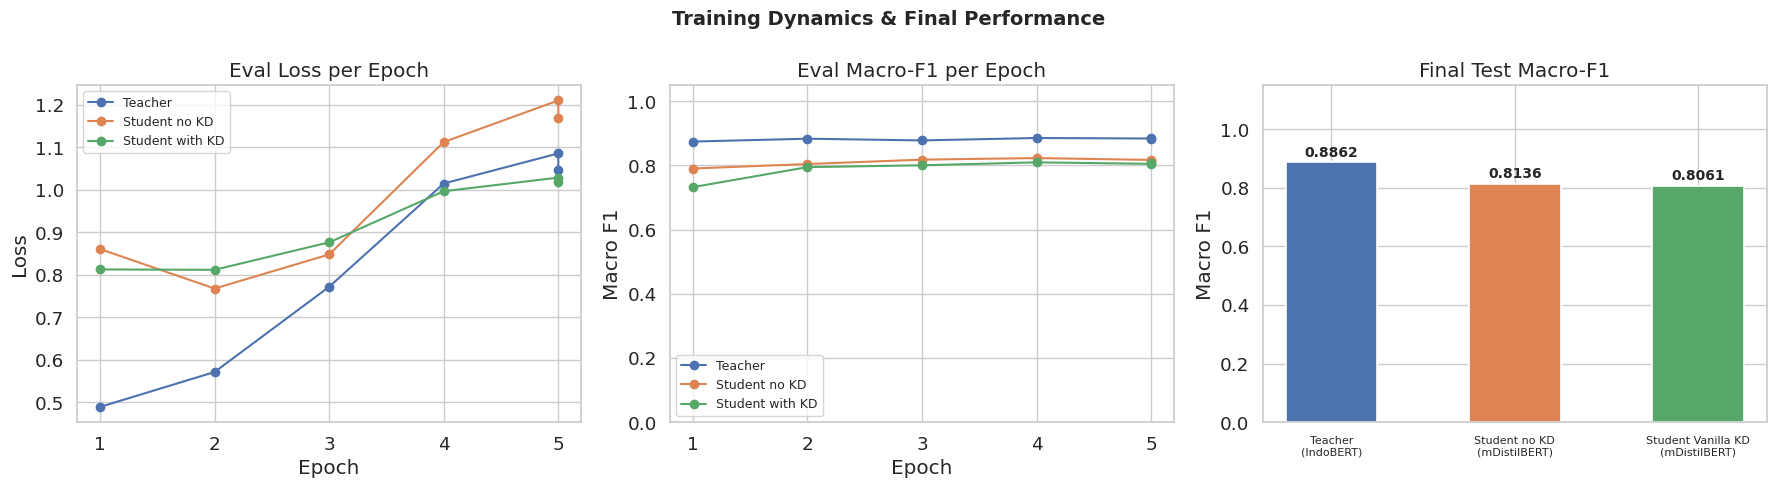

Saved: training_overview.png


In [32]:
# Cell 30: Training dynamics plots
# ─────────────────────────────────────────────────────────────────────────────
callbacks_to_plot = {
    "Teacher":         teacher_cb,
    "Student no KD":   no_kd_cb,
    "Student with KD": kd_cb,
}
if sd_results is not None:
    callbacks_to_plot["Self-Distilled Teacher"] = sd_cb

COLOR_MAP = {
    "Teacher":                         COLORS["Teacher"],
    "Self-Distilled Teacher":          COLORS["Self-Distilled Teacher"],
    "Student no KD":                   COLORS["Student no KD"],
    "Student with KD":                 COLORS["Student with KD"],
    "Teacher (IndoBERT)":              COLORS["Teacher"],
    "Student no KD (mDistilBERT)":     COLORS["Student no KD"],
    "Student Vanilla KD (mDistilBERT)": COLORS["Student with KD"],
    "Self-Distilled Teacher":          COLORS["Self-Distilled Teacher"],
}

fig = plt.figure(figsize=(18, 5))
fig.suptitle("Training Dynamics & Final Performance", fontsize=14, fontweight="bold")

ax1 = fig.add_subplot(1, 3, 1)
for lbl, cb in callbacks_to_plot.items():
    ax1.plot(cb.history["epoch"], cb.history["eval_loss"],
             marker="o", label=lbl, color=COLOR_MAP.get(lbl, "#999"))
ax1.set_title("Eval Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax2 = fig.add_subplot(1, 3, 2)
for lbl, cb in callbacks_to_plot.items():
    ax2.plot(cb.history["epoch"], cb.history["eval_f1"],
             marker="o", label=lbl, color=COLOR_MAP.get(lbl, "#999"))
ax2.set_title("Eval Macro-F1 per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro F1")
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax3 = fig.add_subplot(1, 3, 3)
bar_labels = [r[0] for r in rows]
bar_f1s    = [r[1] for r in rows]
bar_colors = [COLOR_MAP.get(l, "#999") for l in bar_labels]
bars = ax3.bar(range(len(bar_labels)), bar_f1s, color=bar_colors,
               edgecolor="white", linewidth=1.2, width=0.5)
for bar, val in zip(bars, bar_f1s):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax3.set_xticks(range(len(bar_labels)))
ax3.set_xticklabels([l.replace(" (", "\n(") for l in bar_labels], fontsize=8)
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("Macro F1")
ax3.set_title("Final Test Macro-F1")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_overview.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_overview.png")


Map:   0%|          | 0/1268 [00:00<?, ? examples/s]

Map:   0%|          | 0/1268 [00:00<?, ? examples/s]


────────────────────────────────────────────────────────────
Model        : Teacher (IndoBERT)
  Macro-F1   : 0.8862
  Weighted-F1: 0.9152

              precision    recall  f1-score   support

    negative     0.8785    0.9132    0.8955       380
     neutral     0.8466    0.7797    0.8118       177
    positive     0.9521    0.9508    0.9514       711

    accuracy                         0.9156      1268
   macro avg     0.8924    0.8812    0.8862      1268
weighted avg     0.9153    0.9156    0.9152      1268



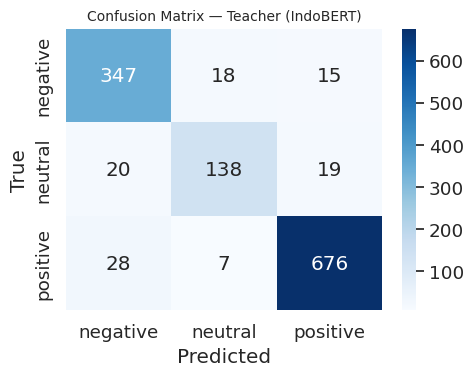

Saved: cm_teacher_(indobert).png

────────────────────────────────────────────────────────────
Model        : Student (no KD)
  Macro-F1   : 0.8136
  Weighted-F1: 0.8592

              precision    recall  f1-score   support

    negative     0.7793    0.8737    0.8238       380
     neutral     0.7566    0.6497    0.6991       177
    positive     0.9319    0.9044    0.9179       711

    accuracy                         0.8596      1268
   macro avg     0.8226    0.8093    0.8136      1268
weighted avg     0.8617    0.8596    0.8592      1268



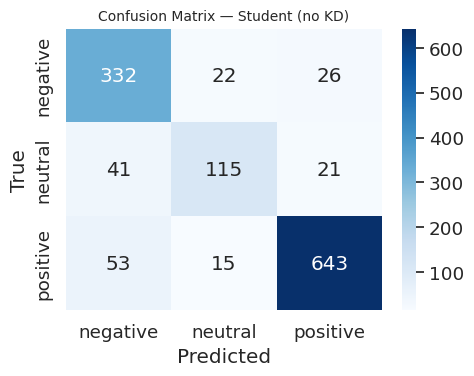

Saved: cm_student_(no_kd).png

────────────────────────────────────────────────────────────
Model        : Student (Vanilla KD)
  Macro-F1   : 0.8061
  Weighted-F1: 0.8513

              precision    recall  f1-score   support

    negative     0.7723    0.8658    0.8164       380
     neutral     0.7267    0.6610    0.6923       177
    positive     0.9295    0.8903    0.9095       711

    accuracy                         0.8509      1268
   macro avg     0.8095    0.8057    0.8061      1268
weighted avg     0.8541    0.8509    0.8513      1268



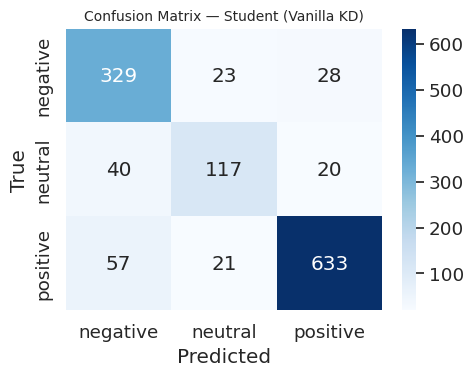

Saved: cm_student_(vanilla_kd).png

TEST SET COMPARISON
               Model Macro-F1 Weighted-F1
  Teacher (IndoBERT)   0.8862      0.9152
     Student (no KD)   0.8136      0.8592
Student (Vanilla KD)   0.8061      0.8513


In [33]:
LABEL_NAMES = [id2label[i] for i in range(num_labels)]
EVAL_DEVICE = torch.device("cuda:0")


def predict_manual(model, dataset, collator, batch_size=32) -> tuple:
    """Manual inference loop — bypass Trainer sepenuhnya, no DataParallel."""
    # Unwrap kalau masih wrapped DataParallel
    raw = model.module if hasattr(model, "module") else model
    raw = raw.to(EVAL_DEVICE).eval()

    from torch.utils.data import DataLoader
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=collator)

    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop("labels", None)
            # Hanya kirim keys yang diterima model
            import inspect
            accepted = set(inspect.signature(raw.forward).parameters)
            batch = {k: v.to(EVAL_DEVICE) for k, v in batch.items() if k in accepted}
            out = raw(**batch)
            all_logits.append(out.logits.cpu())
            if labels is not None:
                all_labels.append(labels.cpu())

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy() if all_labels else None
    return logits, labels


def evaluate_on_test(model, collator, test_ds, model_name: str) -> dict:
    logits, true_ids = predict_manual(model, test_ds, collator)
    pred_ids    = np.argmax(logits, axis=-1)
    f1_macro    = sk_f1(true_ids, pred_ids, average="macro")
    f1_weighted = sk_f1(true_ids, pred_ids, average="weighted")

    print(f"\n{'─' * 60}")
    print(f"Model        : {model_name}")
    print(f"  Macro-F1   : {f1_macro:.4f}")
    print(f"  Weighted-F1: {f1_weighted:.4f}")
    print()
    print(classification_report(true_ids, pred_ids, target_names=LABEL_NAMES, digits=4))

    cm = confusion_matrix(true_ids, pred_ids)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    fname = f"cm_{model_name.lower().replace(' ', '_').replace('/', '-')}.png"
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=100)
    plt.show()
    print(f"Saved: {fname}")
    return {"model": model_name, "macro_f1": f1_macro, "weighted_f1": f1_weighted}


# Re-tokenise test set
t_test = raw_datasets["test"].map(
    lambda ex: teacher_tokenizer(ex["text"], truncation=True,
                                 max_length=MAX_LENGTH, padding=False),
    batched=True,
    remove_columns=[c for c in ["text", "raw_text"] if c in raw_datasets["test"].column_names],
)
s_test = raw_datasets["test"].map(
    lambda ex: student_tokenizer(ex["text"], truncation=True,
                                 max_length=MAX_LENGTH, padding=False),
    batched=True,
    remove_columns=[c for c in ["text", "raw_text"] if c in raw_datasets["test"].column_names],
)
t_test.set_format("torch")
s_test.set_format("torch")

t_coll = DataCollatorWithPadding(teacher_tokenizer)
s_coll = DataCollatorWithPadding(student_tokenizer)

test_results_all = []

# 1. Teacher
test_results_all.append(
    evaluate_on_test(teacher_model, t_coll, t_test, "Teacher (IndoBERT)")
)

# 2. Self-distilled teacher (kalau ada)
if sd_results is not None and sd_trainer is not None:
    test_results_all.append(
        evaluate_on_test(sd_trainer.model, t_coll, t_test, "Teacher Self-Distilled")
    )

# 3. Student no KD
test_results_all.append(
    evaluate_on_test(student_no_kd, s_coll, s_test, "Student (no KD)")
)

# 4. Student Vanilla KD — pakai s_test bukan kd_test_dataset
# (kd_test_dataset punya teacher columns yang tidak dibutuhkan untuk inference)
test_results_all.append(
    evaluate_on_test(student_with_kd, s_coll, s_test, "Student (Vanilla KD)")
)

# Summary
print("\n" + "=" * 62)
print("TEST SET COMPARISON")
print("=" * 62)
df_test_cmp = pd.DataFrame([
    {"Model": r["model"], "Macro-F1": f"{r['macro_f1']:.4f}",
     "Weighted-F1": f"{r['weighted_f1']:.4f}"}
    for r in test_results_all
])
print(df_test_cmp.to_string(index=False))

In [34]:
# Cell 32: Save all models, tokenizers, and results CSV
# ─────────────────────────────────────────────────────────────────────────────
models_to_save = [
    ("teacher",             teacher_model,   teacher_tokenizer),
    ("student-no-kd",       student_no_kd,   student_tokenizer),
    ("student-with-vanilla-kd", student_with_kd, student_tokenizer),
]
if sd_results is not None and sd_trainer is not None:
    models_to_save.insert(1, ("teacher-self-distilled", sd_trainer.model, teacher_tokenizer))

for name, mdl, tok in models_to_save:
    path = os.path.join(OUTPUT_DIR, name)
    os.makedirs(path, exist_ok=True)
    mdl.save_pretrained(path)
    tok.save_pretrained(path)
    print(f"Saved : {path}")

csv_path = os.path.join(OUTPUT_DIR, "results_summary.csv")
df_summary.to_csv(csv_path, index=False)
print(f"\nResults CSV : {csv_path}")
print(f"All outputs → {OUTPUT_DIR}")
print("\n✓ Done!")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved : /kaggle/working/teacher


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved : /kaggle/working/student-no-kd


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved : /kaggle/working/student-with-vanilla-kd

Results CSV : /kaggle/working/results_summary.csv
All outputs → /kaggle/working

✓ Done!
